# Task 1: Exploratory Data Analysis

The goal of this assignment is to predict the `Activity Level`, which likely represents how **physically active** the elderly resident was during a given time period. The following are some hypothesis-driven suggestions based on domain knowledge.

| Feature                                                            | Reason for Influence                                                                                                                      |
| ------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **CO₂ levels** (`CO2_InfraredSensor`, `CO2_ElectroChemicalSensor`) | Higher CO₂ levels often correlate with low ventilation or little movement. A sharp drop or rise might signal movement or appliance usage. |
| **Ambient Light Level**                                            | Lights on/off may signal waking/sleeping patterns or movement between rooms.                                                              |
| **Temperature**                                                    | Activity may correspond with HVAC usage or time of day — e.g., more active when cooler or warmer.                                         |
| **HVAC Operation Mode**                                            | Indirect clue — HVAC running may align with times of activity (heating in morning, cooling during workouts).                              |
| **Time of Day**                                                    | Strong circadian patterns — more active in the day, less at night.                                                                        |
| **Humidity**                                                       | Might reflect bathing, cooking, or time of day — potentially linked to movement.                                                          |
| **Metal Oxide Sensors (1–4)**                                      | These sensors detect volatile organic compounds (VOCs), possibly linked to human presence, cooking, or cleaning.                          |
| **CO\_GasSensor**                                                  | CO levels may fluctuate during cooking or appliance usage, indicating activity.                                                           |
| **Session ID**                                                     | Likely a technical grouping field — probably not useful unless you extract session-based patterns.                                        |


## 1. Obtaining The Data From 'data/gas_monitoring.db'

In [116]:
from sqlalchemy import create_engine, MetaData
import os

# Use the relative path
db_path = "data/gas_monitoring.db"
if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found at: {db_path}")
engine = create_engine(f"sqlite:///{db_path}")

# Reflect the schema
metadata = MetaData()
metadata.reflect(bind=engine)

# Show table names
print(metadata.tables.keys())


dict_keys(['gas_monitoring'])


In [117]:
from sqlalchemy import Table, select

# Load the bank_marketing table
gas_monitoring = Table('gas_monitoring', metadata, autoload_with=engine)

In [118]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect(db_path) 

# Load the bank_marketing table into a DataFrame
df = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)

## 2. Summary of Statistics

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   10000 non-null  float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  9294 non-null   float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     10000 non-null  float64
 7   MetalOxideSensor_Unit3     7434 non-null   float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               8631 non-null   object 
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        7468 non-null   object 
 13  Activity Level             10000 non-null  obje

In [120]:
df.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,Session ID
count,10000.000000,10000.000000,10000.000000,9294.000000,10000.000000,10000.000000,7434.000000,10000.000000,10000.000000
mean,42.564132,51.125461,110.356504,578.333884,470.363051,728.265041,681.359029,611.956357,5418.640400
std,74.350143,20.565964,25.056797,22.669681,51.353223,43.303414,59.994204,42.855167,2588.467375
min,14.940000,-49.660000,-14.670000,408.600000,286.830000,554.280000,457.810000,412.790000,1374.000000
25%,19.000000,47.680000,99.077500,559.225000,439.630000,707.957500,658.222500,585.555000,3074.000000
50%,20.530000,51.300000,113.100000,578.890000,468.810000,726.635000,680.085000,609.005000,5214.000000
75%,23.130000,53.850000,124.022500,595.180000,493.940000,746.492500,704.405000,635.480000,7395.000000
max,298.930000,199.590000,236.010000,637.900000,632.890000,902.210000,905.150000,736.110000,9658.000000


## 3. Analysis - Before Data Preprocessing

In this section, we will be doing an analysis of each feature so that we can get a better understanding of the dataset given to us. We will not be editing the dataset in this section. Any entries that needs to be edited (eg. imputed, normalised, etc.) will be done in section 4 to 9.

Standard function that is used throughout this section

In [121]:
import matplotlib.pyplot as plt

def show_frequency_by_feature(column: str, order=None):
    column_counts = df[column].value_counts().sort_index() if order is None else df[column].value_counts().reindex(order)
    
    plt.figure(figsize=(14, 6))
    column_counts.plot(kind='bar', edgecolor='black')
    plt.title("Number of Elderly Residents by " + column)
    plt.xlabel(column)
    plt.ylabel("Number of Elderly Residents")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

### 3.1 Time of Day    

In [122]:
print(df['Time of Day'].unique())
print(df['Time of Day'].value_counts())
print(df['Time of Day'].isnull().sum())
print(df['Time of Day'].dtype)

['morning' 'night' 'afternoon' 'evening']
Time of Day
afternoon    2605
evening      2485
night        2456
morning      2454
Name: count, dtype: int64
0
object


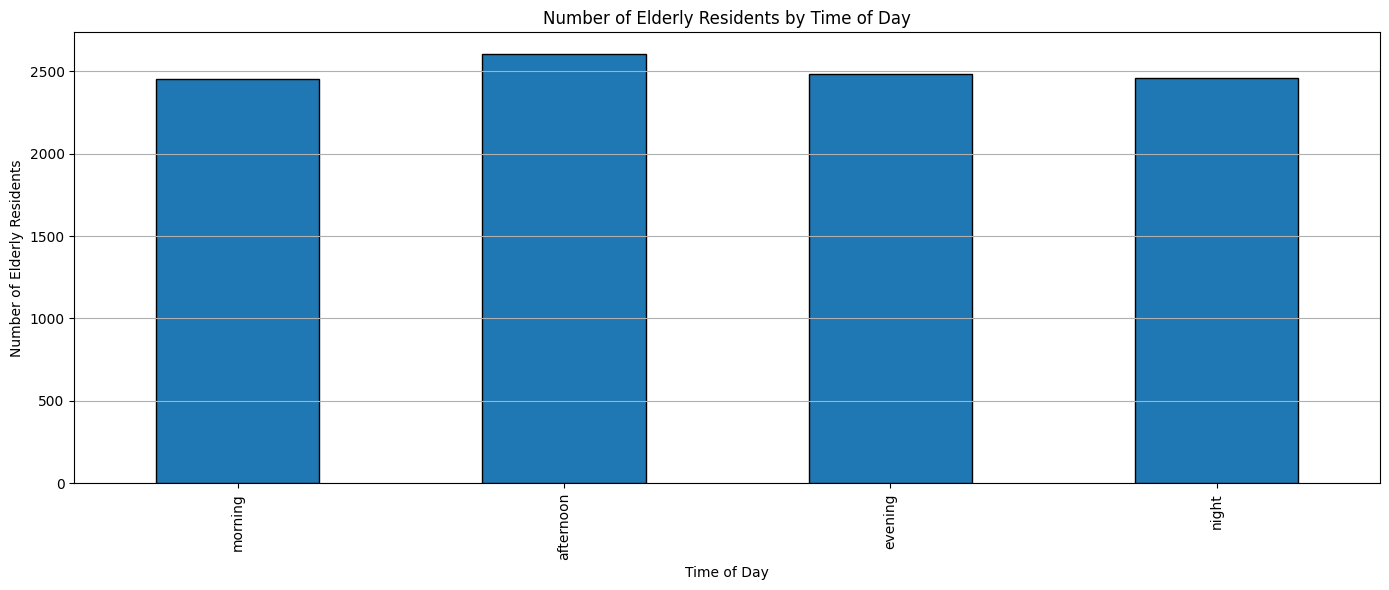

In [123]:
show_frequency_by_feature('Time of Day', order=['morning', 'afternoon', 'evening', 'night'])

### 3.2 Temperature

In [124]:
import seaborn as sns

print(df['Temperature'].describe())
print("Number of Null values:", df['Temperature'].isnull().sum())
print(df['Temperature'].dtype)

count    10000.000000
mean        42.564132
std         74.350143
min         14.940000
25%         19.000000
50%         20.530000
75%         23.130000
max        298.930000
Name: Temperature, dtype: float64
Number of Null values: 0
float64


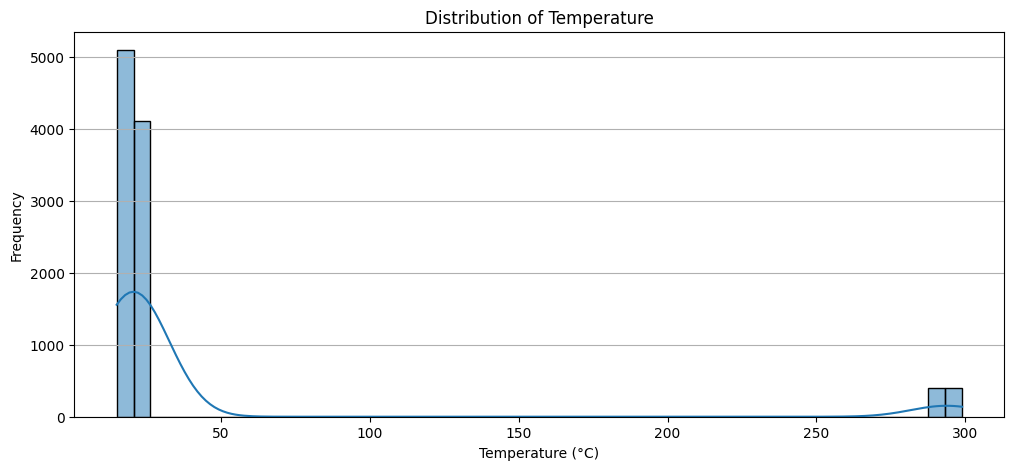

In [125]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Temperature'], kde=True, bins=50)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

It seems that there are data entries with temperature readings beyond 250 degree celcius which seems really unreasonable. I am going to investigate these data.

In [126]:
df[df['Temperature'] > 50]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
8,afternoon,292.59,47.92,74.10,624.58,564.75,798.29,753.47,674.28,extremely low,7241,maintenance_mode,very_bright,Low Activity
23,morning,292.40,54.37,115.14,574.75,496.94,742.15,NaN,638.83,low,1826,ventilation_only,very_bright,Moderate Activity
37,afternoon,293.66,49.30,72.23,NaN,383.95,761.69,718.53,635.70,low,7241,eco_mode,very_bright,Moderate Activity
49,afternoon,293.59,51.07,92.64,619.54,421.56,749.11,704.69,628.91,low,7241,eco_mode,None,Low_Activity
64,evening,295.06,45.25,124.91,576.13,483.46,719.69,676.75,595.01,medium,2679,maintenance_mode,very_bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9963,afternoon,294.79,44.75,79.87,558.68,512.18,761.98,716.79,663.59,low,2586,eco_mode,very_bright,ModerateActivity
9967,afternoon,294.75,45.52,83.66,563.99,526.75,758.68,NaN,666.72,low,2586,cooling_active,bright,High Activity
9969,night,294.40,54.01,110.34,550.65,503.14,722.77,668.96,607.85,low,6817,cooling_active,bright,Low Activity
9976,night,294.14,57.61,136.81,561.46,446.62,703.95,663.04,578.16,low,4761,maintenance_mode,bright,Low Activity


In [127]:
df[df['Temperature'] > 50]['Temperature'].describe()

count    805.000000
mean     293.713839
std        2.238300
min      288.490000
25%      292.080000
50%      293.240000
75%      295.610000
max      298.930000
Name: Temperature, dtype: float64

There are 805 outliers where temperature > 50 degree celcius. These values range from 288 degree celcius to 296 degree celcius - clearly unrealistic for indoor environments. Their presence is likely due to: Sensor malfunction, data corruption, etc.

**Temperature Outliers**

We identified 805 rows with indoor temperature readings exceeding 280°C — an implausible value for residential environments. These records were likely due to sensor malfunctions or synthetic data contamination. They will be removed/imputed from the dataset to ensure accurate downstream analysis during the data preprocessing phase.

### 3.3 Humidity

In [128]:
print(df['Humidity'].describe())
print("Number of Null values:", df['Humidity'].isnull().sum())
print("Data type:", df['Humidity'].dtype)

count    10000.000000
mean        51.125461
std         20.565964
min        -49.660000
25%         47.680000
50%         51.300000
75%         53.850000
max        199.590000
Name: Humidity, dtype: float64
Number of Null values: 0
Data type: float64


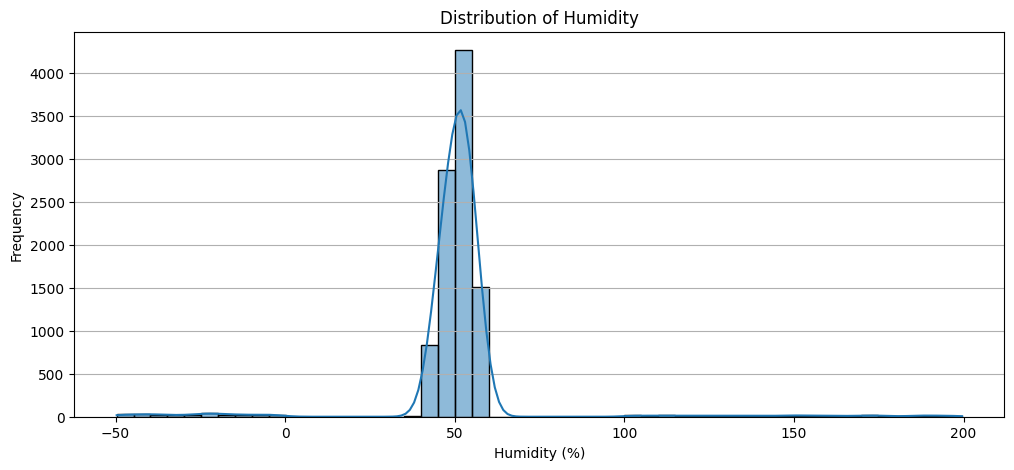

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['Humidity'], kde=True, bins=50)
plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [130]:
df[df['Humidity'] < 20]['Humidity'].describe()

count    269.000000
mean     -25.723457
std       14.208515
min      -49.660000
25%      -38.400000
50%      -24.180000
75%      -14.370000
max       -1.170000
Name: Humidity, dtype: float64

In [131]:
df[df['Humidity'] > 80]['Humidity'].describe()

count    234.000000
mean     149.004744
std       28.989983
min      101.140000
25%      123.307500
50%      148.630000
75%      173.062500
max      199.590000
Name: Humidity, dtype: float64

**Humidity Outliers**

We identified 269 rows with negative humidity readings — an implausible value for residential environments. These records were likely due to sensor malfunctions or synthetic data contamination. They will be removed/imputed from the dataset to ensure accurate downstream analysis during the data preprocessing phase.

We also identified 234 rows with humidity readings greater than 100% — an implausible value for residential environments. These records were likely due to sensor malfunctions or synthetic data contamination. They will be removed/imputed from the dataset to ensure accurate downstream analysis during the data preprocessing phase.

### 3.4 CO2_InfraredSensor

In [132]:
print("Null values:", df['CO2_InfraredSensor'].isnull().sum())
print(df['CO2_InfraredSensor'].describe())

Null values: 0
count    10000.000000
mean       110.356504
std         25.056797
min        -14.670000
25%         99.077500
50%        113.100000
75%        124.022500
max        236.010000
Name: CO2_InfraredSensor, dtype: float64


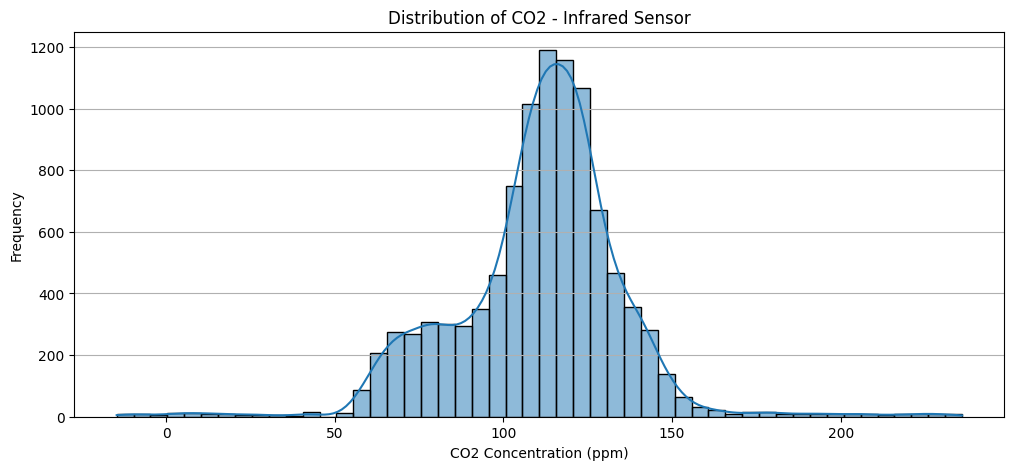

In [133]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['CO2_InfraredSensor'], bins=50, kde=True)
plt.title('Distribution of CO2 - Infrared Sensor')
plt.xlabel('CO2 Concentration (ppm)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [134]:
df[df['CO2_InfraredSensor'] < 0.1]['CO2_InfraredSensor'].describe()

count    22.000000
mean     -8.966818
std       4.015155
min     -14.670000
25%     -12.570000
50%      -8.815000
75%      -6.772500
max      -0.820000
Name: CO2_InfraredSensor, dtype: float64

In [135]:
df[df['CO2_InfraredSensor'] < 0.1]['CO2_InfraredSensor']

399     -4.35
1539    -6.63
1712   -12.61
2686    -8.01
3332   -13.21
3654    -9.45
3674   -12.75
4492    -7.20
4656   -14.13
4966    -3.51
5966   -11.96
6618   -14.38
6660   -12.45
6866   -14.67
7174    -8.92
7569    -8.71
7820    -3.57
8213    -7.88
8356   -10.33
8443    -0.82
8526    -4.33
9602    -7.40
Name: CO2_InfraredSensor, dtype: float64

**CO2_InfraredSensor**

This feature represents carbon dioxide concentrations measured via infrared sensors. While most readings fall in a reasonable range, 22 entries were found with negative CO₂ values — which are physically implausible. These likely indicate faulty sensors or synthetic data contamination and will be addressed during the data cleaning phase.


### 3.5 CO2_ElectroChemicalSensor

In [136]:
print("Null values:", df['CO2_ElectroChemicalSensor'].isnull().sum())
print(df['CO2_ElectroChemicalSensor'].describe())

Null values: 706
count    9294.000000
mean      578.333884
std        22.669681
min       408.600000
25%       559.225000
50%       578.890000
75%       595.180000
max       637.900000
Name: CO2_ElectroChemicalSensor, dtype: float64


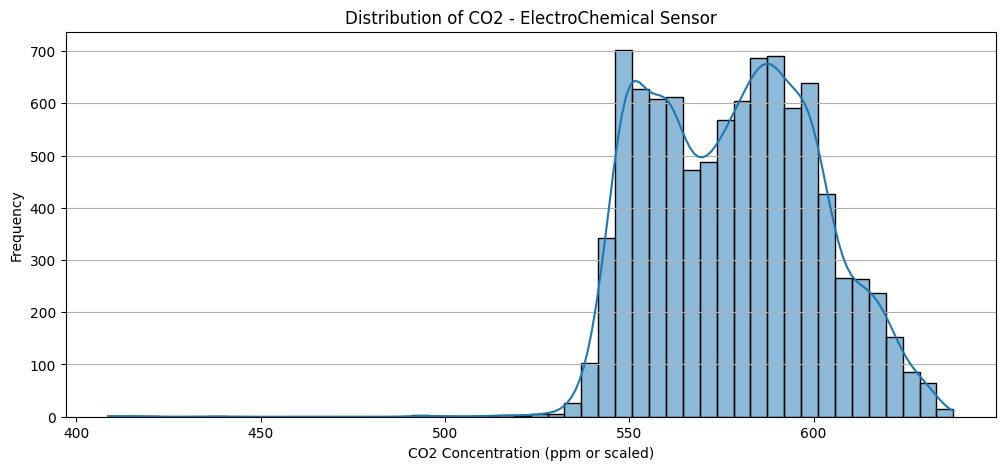

In [137]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['CO2_ElectroChemicalSensor'], bins=50, kde=True)
plt.title('Distribution of CO2 - ElectroChemical Sensor')
plt.xlabel('CO2 Concentration (ppm or scaled)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()


**CO2_ElectroChemicalSensor**

This feature measures carbon dioxide levels via electrochemical sensors. The distribution appears stable and within a reasonable indoor range (408–637). However, 706 entries are missing and will require imputation or removal in the data cleaning phase. No negative or suspicious values were observed.


### 3.6 MetalOxideSensor_Unit1

In [138]:
print("Null values:", df['MetalOxideSensor_Unit1'].isnull().sum())
print(df['MetalOxideSensor_Unit1'].describe())

Null values: 0
count    10000.000000
mean       470.363051
std         51.353223
min        286.830000
25%        439.630000
50%        468.810000
75%        493.940000
max        632.890000
Name: MetalOxideSensor_Unit1, dtype: float64


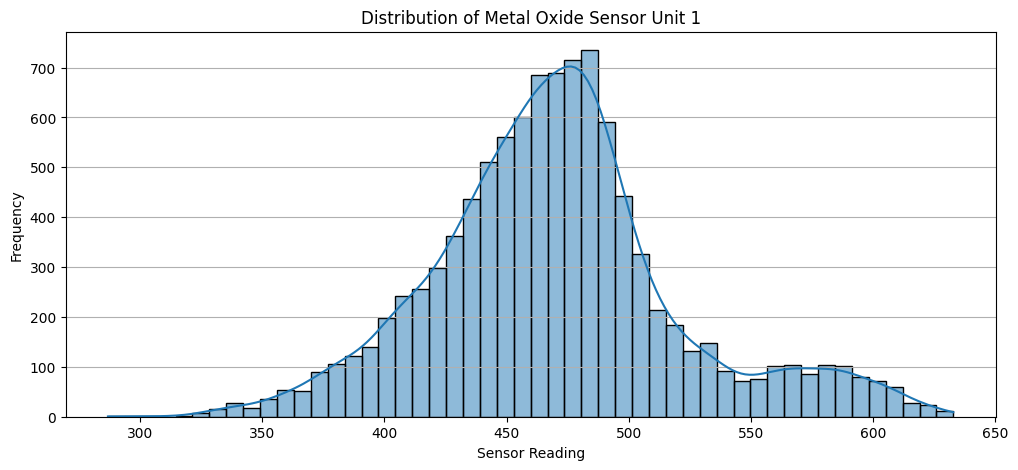

In [139]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['MetalOxideSensor_Unit1'], bins=50, kde=True)
plt.title('Distribution of Metal Oxide Sensor Unit 1')
plt.xlabel('Sensor Reading')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

**MetalOxideSensor_Unit1**

This feature reflects volatile gas concentrations measured via a metal oxide sensor. The values range from ~287 to ~633, with a moderate right-skewed distribution. Although there are no nulls, we observe significant outliers on both ends. These may indicate environmental anomalies or sensor artifacts and will be considered during the data cleaning phase.


### 3.7 MetalOxideSensor_Unit2

In [140]:
print("Null values:", df['MetalOxideSensor_Unit2'].isnull().sum())
print(df['MetalOxideSensor_Unit2'].describe())

Null values: 0
count    10000.000000
mean       728.265041
std         43.303414
min        554.280000
25%        707.957500
50%        726.635000
75%        746.492500
max        902.210000
Name: MetalOxideSensor_Unit2, dtype: float64


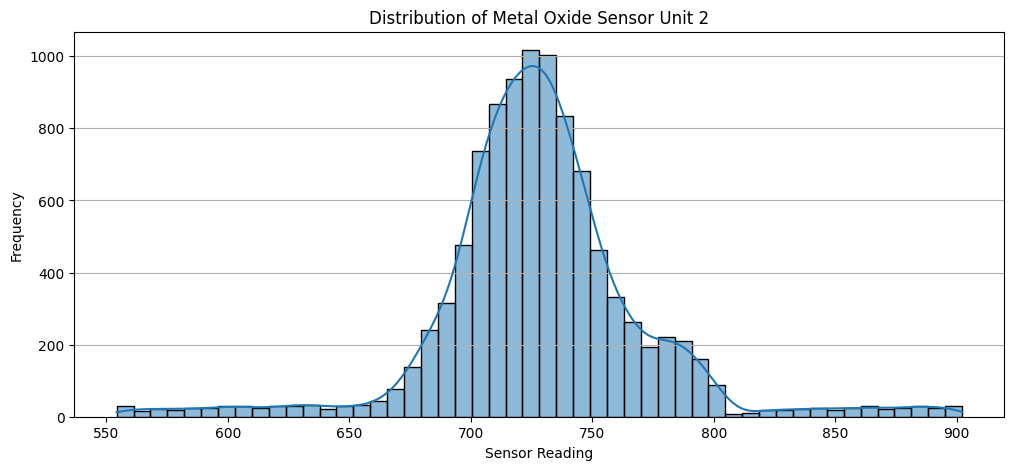

In [141]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['MetalOxideSensor_Unit2'], bins=50, kde=True)
plt.title('Distribution of Metal Oxide Sensor Unit 2')
plt.xlabel('Sensor Reading')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

**MetalOxideSensor_Unit2**

This feature captures gas readings from a metal oxide sensor. The data is approximately normally distributed with a slight right skew. It ranges from ~554 to ~902 with no missing values. Both tails contain outliers, particularly above 820, which will be considered during the data preprocessing phase.


### 3.8 MetalOxideSensor_Unit3

In [142]:
print("Null values:", df['MetalOxideSensor_Unit3'].isnull().sum())
print(df['MetalOxideSensor_Unit3'].describe())

Null values: 2566
count    7434.000000
mean      681.359029
std        59.994204
min       457.810000
25%       658.222500
50%       680.085000
75%       704.405000
max       905.150000
Name: MetalOxideSensor_Unit3, dtype: float64


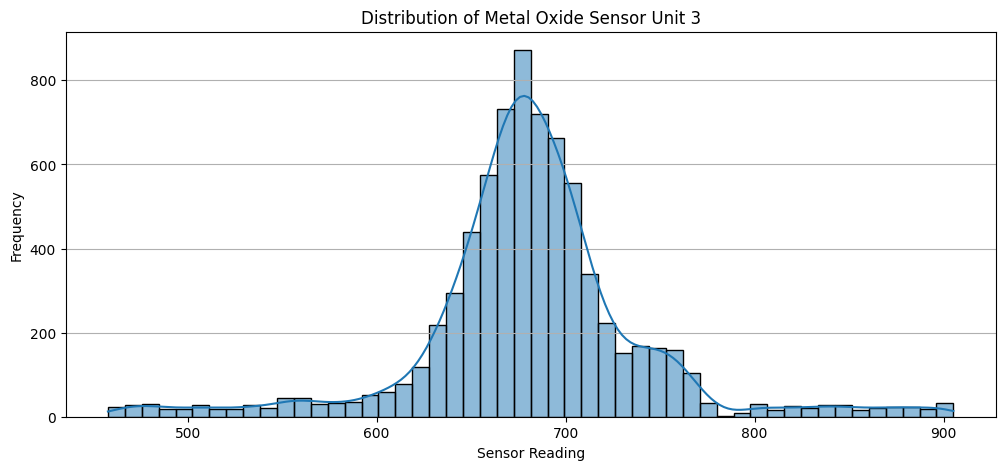

In [143]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['MetalOxideSensor_Unit3'], bins=50, kde=True)
plt.title('Distribution of Metal Oxide Sensor Unit 3')
plt.xlabel('Sensor Reading')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

**MetalOxideSensor_Unit3**

This attribute measures gas levels using a third metal oxide sensor. While its values are roughly normally distributed with a mean around 681, there are 2,566 missing entries (26%) and a considerable number of outliers at both extremes. 

### 3.9 MetalOxideSensor_Unit4


In [144]:
print("Null values:", df['MetalOxideSensor_Unit4'].isnull().sum())
print(df['MetalOxideSensor_Unit4'].describe())

Null values: 0
count    10000.000000
mean       611.956357
std         42.855167
min        412.790000
25%        585.555000
50%        609.005000
75%        635.480000
max        736.110000
Name: MetalOxideSensor_Unit4, dtype: float64


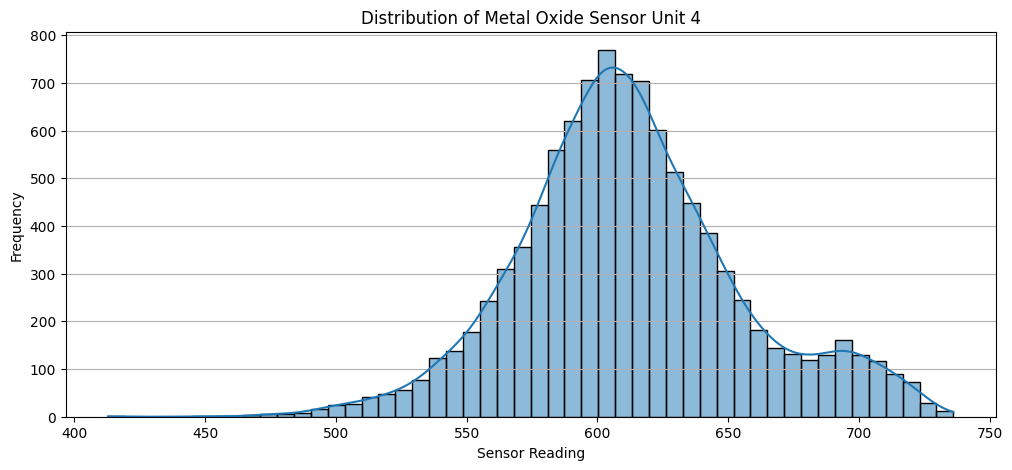

In [145]:
# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(df['MetalOxideSensor_Unit4'], bins=50, kde=True)
plt.title('Distribution of Metal Oxide Sensor Unit 4')
plt.xlabel('Sensor Reading')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

**MetalOxideSensor_Unit4**

This sensor measures volatile gases using a fourth metal oxide unit. The readings are normally distributed around a mean of ~612, with values ranging from ~413 to ~736. No missing values were found. Some outliers exist on the lower end, but they do not appear extreme or problematic. Overall, this sensor shows clean behavior compared to Unit 3.

### 3.10 CO_GasSensor 

In [146]:
print("Null values:", df['CO_GasSensor'].isnull().sum())
print(df['CO_GasSensor'].describe())

Null values: 1369
count     8631
unique       5
top        low
freq      4346
Name: CO_GasSensor, dtype: object


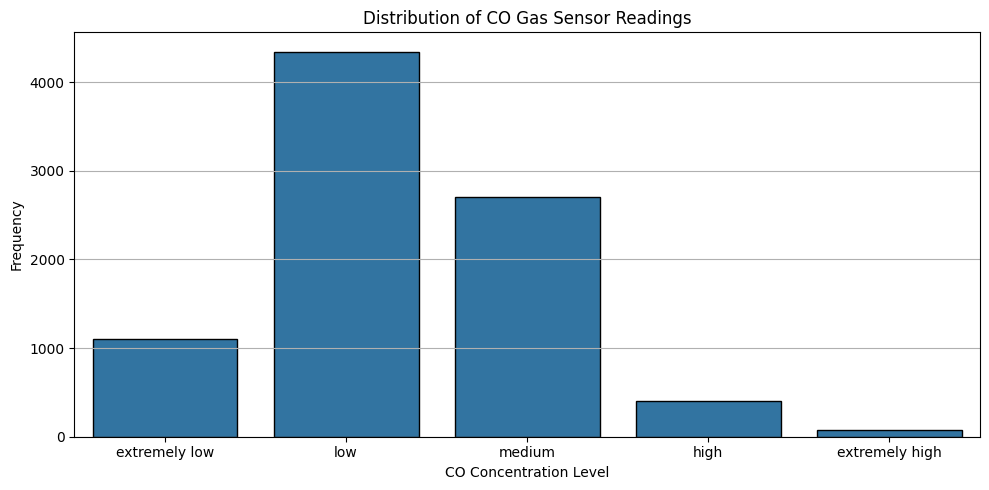

In [147]:
# Define logical category order
co_order = ['extremely low', 'low', 'medium', 'high', 'extremely high']

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='CO_GasSensor', order=co_order, edgecolor='black')
plt.title('Distribution of CO Gas Sensor Readings')
plt.xlabel('CO Concentration Level')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**CO_GasSensor**

This column represents carbon monoxide concentration using qualitative labels rather than numeric values. It includes five categories: extremely low, low, medium, high, and extremely high. The majority of entries fall under "low" and "medium", with very few outliers at the extreme ends. 1,369 values (~13.7%) are missing. This feature may need preprocessing via ordinal encoding or mapping and will require imputation or exclusion during data cleaning.


### 3.11 Session ID 

In [148]:
print("Null values:", df['Session ID'].isnull().sum())
print("Unique values:", df['Session ID'].nunique())
print(df['Session ID'].describe())

Null values: 0
Unique values: 38
count    10000.000000
mean      5418.640400
std       2588.467375
min       1374.000000
25%       3074.000000
50%       5214.000000
75%       7395.000000
max       9658.000000
Name: Session ID, dtype: float64


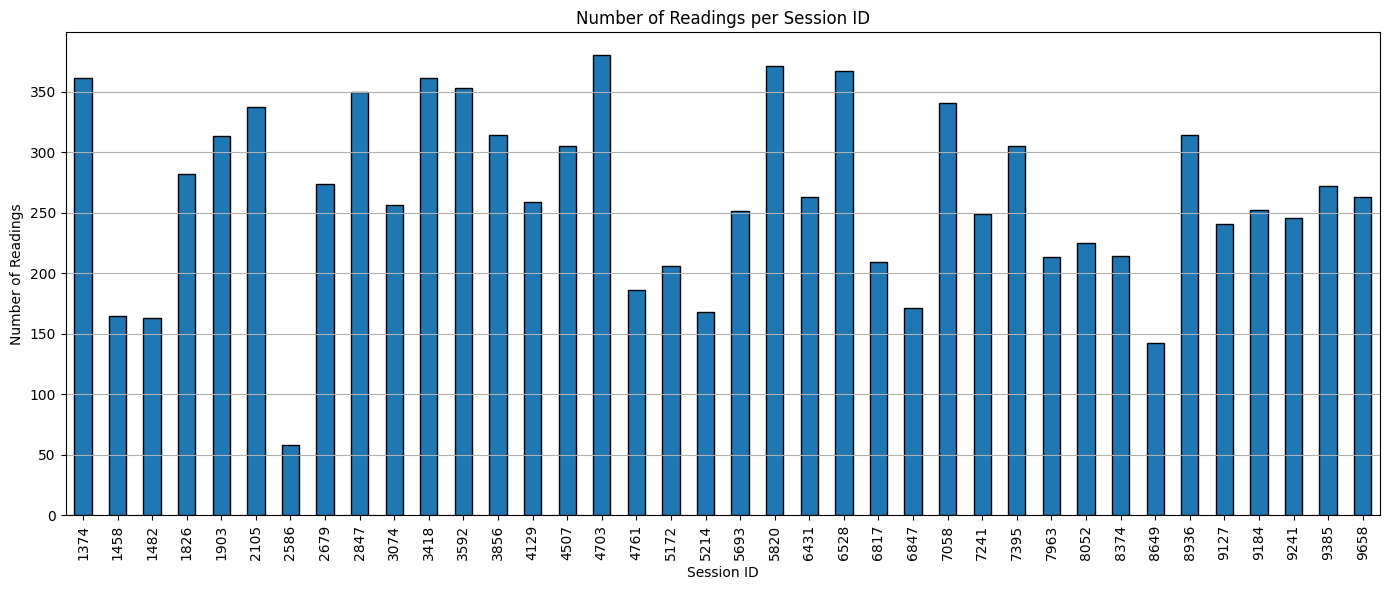

In [149]:
# Plot frequency of each Session ID
session_counts = df['Session ID'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
session_counts.plot(kind='bar', edgecolor='black')
plt.title('Number of Readings per Session ID')
plt.xlabel('Session ID')
plt.ylabel('Number of Readings')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Session ID**

The dataset consists of 38 unique session IDs, each representing a data collection period. The number of readings per session ranges roughly from 150 to 370, with most sessions contributing between 250–350 entries. This relatively balanced distribution ensures that no single session dominates the dataset. 

### 3.12 HVAC Operation Mode

In [150]:
print("Null values:", df['HVAC Operation Mode'].isnull().sum())
print("Unique values:", df['HVAC Operation Mode'].nunique())
print(df['HVAC Operation Mode'].value_counts())

Null values: 0
Unique values: 23
HVAC Operation Mode
cooling_active      1504
maintenance_mode    1501
heating_active      1491
eco_mode            1437
ventilation_only    1435
off                 1429
COOLING_ACTIVE       120
OFF                  106
ECO_MODE             106
Off                  101
MAINTENANCE_MODE     101
VENTILATION_ONLY      99
HEATING_ACTIVE        88
Heating_Active        63
Ventilation_Only      53
Maintenance_Mode      51
Heating_active        49
Maintenance_mode      49
Eco_Mode              48
Eco_mode              48
Ventilation_only      42
Cooling_active        41
Cooling_Active        38
Name: count, dtype: int64


**HVAC Operation Mode**

This attribute describes the current operation mode of the HVAC system (e.g., cooling, heating, ventilation). While there are 23 unique raw categories, these include redundant variants due to inconsistent casing and formatting. No missing values are present. Cleaning and encoding this feature will be essential during preprocessing.

### 3.13 Ambient Light Level

In [151]:
print("Null values:", df['Ambient Light Level'].isnull().sum())
print("Unique values:", df['Ambient Light Level'].nunique())
print(df['Ambient Light Level'].value_counts())

Null values: 2532
Unique values: 5
Ambient Light Level
very_bright    2857
bright         2200
moderate       1260
dim             720
very_dim        431
Name: count, dtype: int64


**Ambient Light Level**

This feature represents indoor lighting conditions using five ordinal levels: very_dim, dim, moderate, bright, and very_bright. Most readings fall under bright and very_bright. However, 2,532 values (~25%) are missing, which will require imputation or exclusion during data cleaning. Given the ordinal nature of this feature, it is suitable for ordinal encoding before modeling.

### 3.14 Activity Level       

In [152]:
print("Null values:", df['Activity Level'].isnull().sum())
print("Unique values:", df['Activity Level'].nunique())
print(df['Activity Level'].value_counts())

Null values: 0
Unique values: 6
Activity Level
Low Activity         5231
Moderate Activity    2808
High Activity        1088
ModerateActivity      307
LowActivity           293
Low_Activity          273
Name: count, dtype: int64


**Activity Level (Target Variable)**

This is the target variable representing residents' activity level, with three conceptual classes: low, moderate, and high. However, the column currently contains six raw values due to inconsistencies in casing, spacing, and formatting. These will be normalized during data cleaning. No missing values are present. 

## 4. Normalisation of Text Fields

Now that we have completed a brief analysis of each variable, we are ready to proceed with data preprocessing. We will start with normalising the text fields. In our earlier analysis, we noticed that the columns `HVAC Operation Mode` and `Activity Level` use an inconsistent naming convention. Hence, we need to normalise the text fields. 

### 4.1 Normalisation of Text Fields - HVAC Operation Mode

In [153]:
HVAC_Operation_Mode_Mapping = {
    'cooling_active'      : 'Cooling_Active',
    'maintenance_mode'    : 'Maintenance_Mode',
    'heating_active'      : 'Heating_Active',
    'eco_mode'            : 'Eco_Mode',
    'ventilation_only'    : 'Ventilation_Only',
    'off'                 : 'Off',
    'COOLING_ACTIVE'      : 'Cooling_Active',
    'OFF'                 : 'Off',
    'ECO_MODE'            : 'Eco_Mode',
    'Off'                 : 'Off',
    'MAINTENANCE_MODE'    : 'Maintenance_Mode',
    'VENTILATION_ONLY'    : 'Ventilation_Only',
    'HEATING_ACTIVE'      : 'Heating_Active',
    'Heating_Active'      : 'Heating_Active',
    'Ventilation_Only'    : 'Ventilation_Only',
    'Maintenance_Mode'    : 'Maintenance_Mode',
    'Heating_active'      : 'Heating_Active',
    'Maintenance_mode'    : 'Maintenance_Mode',
    'Eco_Mode'            : 'Eco_Mode',
    'Eco_mode'            : 'Eco_Mode',
    'Ventilation_only'    : 'Ventilation_Only',
    'Cooling_active'      : 'Cooling_Active',
    'Cooling_Active'      : 'Cooling_Active',
}

df['HVAC Operation Mode'] = df['HVAC Operation Mode'].map(HVAC_Operation_Mode_Mapping)

print("Unique values:", df['HVAC Operation Mode'].nunique())
print(df['HVAC Operation Mode'].value_counts())
print('Num of rows:', df['HVAC Operation Mode'].count())

Unique values: 6
HVAC Operation Mode
Cooling_Active      1703
Maintenance_Mode    1702
Heating_Active      1691
Eco_Mode            1639
Off                 1636
Ventilation_Only    1629
Name: count, dtype: int64
Num of rows: 10000


### 4.2 Normalisation of Text Fields - Activity Level

In [154]:
Activity_Level_Mapping = {
    'Low Activity'        : 'Low Activity',
    'Moderate Activity'   : 'Moderate Activity',
    'High Activity'       : 'High Activity',
    'ModerateActivity'    : 'Moderate Activity',
    'LowActivity'         : 'Low Activity',
    'Low_Activity'        : 'Low Activity',
}

df['Activity Level'] = df['Activity Level'].map(Activity_Level_Mapping)

print("Unique values:", df['Activity Level'].nunique())
print(df['Activity Level'].value_counts())
print('Num of rows:', df['Activity Level'].count())

Unique values: 3
Activity Level
Low Activity         5797
Moderate Activity    3115
High Activity        1088
Name: count, dtype: int64
Num of rows: 10000


## 5. Data Cleaning

After normalising the text fields, the next step we need to do is to check if there are any duplicate entries and drop columns that are not relevant in predicting the `Activity Level` of the elderly.

### 5.1 Checking for duplicate entries

In [155]:
df.duplicated().sum()

np.int64(201)

In [156]:
# Here, I took a look at the rows that we duplicated. Uncomment to see the duplicate entries

# duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
# print(duplicate_rows)

This tells us that there are 201 dulicate entries that need to be removed. Considering the wide range of data features that we are collecting, it is highly unlikely that there are data entries with exactly the same values. It is highly probable that the dataset was corrupted and duplicated some of the data. Hence, I have decided to drop these values.

In [157]:
df = df.drop_duplicates()

### 5.2 Dropping the Session ID 

`Session ID` is likely a technical grouping field. It is probably not useful unless I extract session-based patterns. Hence, I have decided to drop this column, which I deem to be not relevant in predicting `Activity Level`.

In [158]:
# 'Session ID' is a unique identifier and not relevant for prediction → dropped from dataset
if 'Session ID' in df.columns:
    df = df.drop(columns=['Session ID'])

## 6.  Missing Values

In our earlier analysis, we noticed that there were three columns with missing entries - `CO2_ElectroChemicalSensor`, `MetalOxideSensor_Unit3` and `Ambient Light Level`. In this section, we will discuss how we intend to deal with these missing values

| Column                      | Missing Count | % Missing  | Suggested Action                        |
| --------------------------- | ------------- | ---------- | --------------------------------------- |
| `CO2_ElectroChemicalSensor` | 706           | **7.06%**  | **Median**                              |
| `MetalOxideSensor_Unit3`    | 2,566         | **25.66%** | **KNN**                                 |
| `Ambient Light Level`       | 2,532         | **25.32%** | **Time-aware imputation** or **Median** |


Notice the number of missing values are more than 5% of our data. Hence, it is not a good idea to remove a huge chunk of entries that could be useful when fitting our model to our data. Instead, we will be imputing the missing values. For info on why we decided to 

- Use the median for `CO2_ElectroChemicalSensor`
- Use KNNImputer for `MetalOxideSensor_Unit3`
- Use Time-Aware Imputation for `Ambient Light Level`

will be explained in the relevant subsections below.

### 6.1 CO2_ElectroChemicalSensor

We chose to impute missing values in the CO2_ElectroChemicalSensor feature using the median because:

- The feature is continuous and numerical, making mean/median imputation appropriate.
- The missing rate is relatively low (~7%), so a simple imputation won't significantly distort the distribution.
- The median is robust to outliers, which is important for sensor data, as extreme values can occur due to anomalies or faulty readings.
- We observed in our section 3.5 analysis, the mean was 578.3338884 while the median was 578.890000. Both values are very similar. Hence, using either median or mean is completely valid. In this case, we choose to use the median.

In [159]:
median_CO2_ElectroChemicalSensor = df['CO2_ElectroChemicalSensor'].median()
df['CO2_ElectroChemicalSensor'] = df['CO2_ElectroChemicalSensor'].fillna(median_CO2_ElectroChemicalSensor)

In [160]:
# This code was added for my own analysis. Uncomment if you want to see

# print("Null values:", df['CO2_ElectroChemicalSensor'].isnull().sum())
# df['CO2_ElectroChemicalSensor'].describe()

### 6.2 MetalOxideSensor_Unit3

We selected K-Nearest Neighbors (KNN) imputation for MetalOxideSensor_Unit3 because:

- The feature has a moderate level of missingness (~25%), making simple methods like mean or median potentially less accurate and more biased.
- MetalOxideSensor_Unit3 is part of a group of related sensors (Unit1, Unit2, Unit3, Unit4) that are likely to exhibit correlated behavior, since they detect similar gases under similar environmental conditions.
- KNN imputation allows us to estimate the missing values by leveraging patterns in the other Metal Oxide sensor readings, identifying rows with similar sensor profiles and filling in missing values based on those neighbors.
- It is a non-parametric method that adapts to the underlying data distribution and is capable of preserving multivariate relationships between sensor features.

This makes KNN a robust and data-driven imputation strategy for MetalOxideSensor_Unit3, especially given the redundancy and structure among related features.

In [161]:
from sklearn.impute import KNNImputer

metal_cols = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

df[metal_cols] = KNNImputer(n_neighbors=5).fit_transform(df[metal_cols])

In [162]:
# This code was added for my own analysis. Uncomment if you want to see

# print("Null values:", df['MetalOxideSensor_Unit3'].isnull().sum())
# df['MetalOxideSensor_Unit3'].describe()

### 6.3 Ambient Light Level

I am going to see if there is a relationship between the `Time of Day` and `Ambient Light Level`. My hypothesis is that there may be a time-aware imputation. For example, during the night, the elderly is lightly to be sleeping. Hence, the `Ambient Light Level` should be `dim` or `very_dim`.

In [163]:
from pandas.api.types import CategoricalDtype

# Define desired order
time_order = CategoricalDtype(categories=['morning', 'afternoon', 'evening', 'night'], ordered=True)

# Apply the order to the column
df['Time of Day'] = df['Time of Day'].astype(time_order)

df.groupby('Time of Day', observed=False)['Ambient Light Level'].describe()

,count,unique,top,freq
Time of Day,,,,
morning,1812,5,very_bright,716
afternoon,1888,5,very_bright,672
evening,1763,5,very_bright,679
night,1824,5,very_bright,725


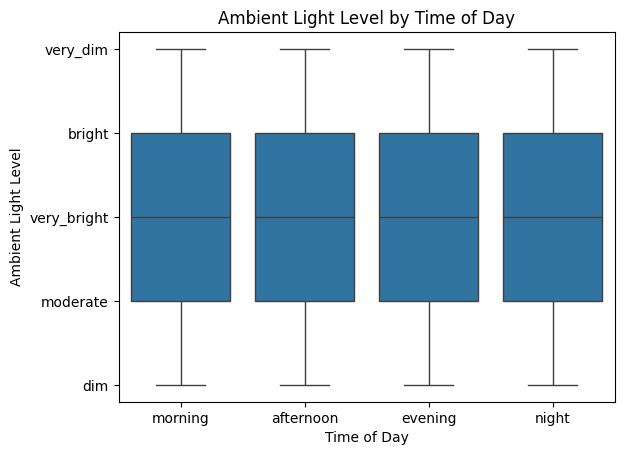

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='Time of Day', y='Ambient Light Level')
plt.title("Ambient Light Level by Time of Day")
plt.show()

“Although we considered time-aware imputation for Ambient Light Level, analysis showed that 'very_bright' was the most frequent value across all time periods. Therefore, we imputed missing entries with `very_bright` globally to preserve consistency while keeping the imputation logic simple.”

In [165]:
# 2. Simple imputation for 'Ambient Light Level' using global mode
df['Ambient Light Level'] = df['Ambient Light Level'].fillna('very_bright')

In [166]:
# 3. Optional: Group summary to confirm ordering and values
summary = df.groupby('Time of Day', observed=True)['Ambient Light Level'].describe()
print(summary)

            count unique          top  freq
Time of Day                                
morning      2413      5  very_bright  1317
afternoon    2554      5  very_bright  1338
evening      2433      5  very_bright  1349
night        2399      5  very_bright  1300


"We observed that `very_bright` was the most common Ambient Light Level across all times of day. Since its dominance was consistent, we chose a simple and consistent strategy by imputing all missing values with 'very_bright'. We also explicitly ordered the Time of Day column to reflect its natural temporal progression."

### 6.4 CO_GasSensor

In [167]:
df = df.dropna(subset=['CO_GasSensor'])

CO_GasSensor contained approximately 13.7% missing values. Given the relatively large size of the dataset (10,000 rows), we opted to drop rows with missing values in this column. This approach avoids introducing potential bias from imputation and retains over 8,600 clean rows for modeling and analysis.

## 7. Invalid Values

In our section 3 analysis, we noticed that there were some clear invalid values in our data. They are listed below:

- In the `Temperature` column, 805 entries had temperature readings beyond 280 degree celcius which is clearly not possible
- In the `Humidity` column, 269 entries had negative readings
- In the `Humidity` column, 234 entries had readings beyond 100%
- In the `CO2_InfraredSensor` column, 22 entries had negative CO2 readings

In this section, we will be discussing how we plan to settle these invalid values

### 7.1 Invalid Values - Temperature

In this case, we had 805 (> 8%) entries with temperature readings beyond 280 degree celcius. Generally, when the number of entries is beyond 5%, it is recommended to impute the data instead of removing it. However, given our large dataset, I am going to break the industry practice of not removing it. My rationale is that we have a large number of data (10,000) and even if we were to drop all 805 entries, there will still be a large number of entries for our model to learn from. 

Furthermore, imputing these entries may introduce bias to the distribution toward central values. 

In [168]:
# Drop rows where Temperature > 280°C
df = df[df['Temperature'] <= 280]

### 7.2 Invalid Values - Humidity

In the `Humidity` column, in section 3, we noticed that there were 269 (2.6%) entries with negative readings and 234 (2.3%) entries with readings greater than 100%. Given that both of these entries only make a small proportion of the total entries (less than 5%). It is standard practice to drop these entries instead of imputing them.

In [169]:
# Drop rows with invalid humidity values (>100% or <0%)
df = df[(df['Humidity'] >= 0) & (df['Humidity'] <= 100)]

### 7.3 Invalid Values - CO2_InfraredSensor

In section 3, we noticed that the `CO2_InfraredSensor` column has 22 entries with negative readings. Given that both of these entries only make a small proportion of the total entries (less than 1%). It is standard practice to drop these entries instead of imputing them.

In [170]:
# Drop rows with negative CO2_InfraredSensor readings
df = df[df['CO2_InfraredSensor'] >= 0]

## 8. Outliers

**Outlier Detection Strategy**

Outliers can heavily skew model performance, especially in environmental sensor data. To ensure robust analysis while retaining genuine variability, we adopted a dual-method approach using Z-score and IQR. An entry is removed only if it is an outlier under both methods.

We used a slightly relaxed threshold—Z-score > 4 and IQR multiplier of 2—to accommodate natural fluctuations in environmental data. This conservative strategy minimizes removal of genuine edge-case measurements.

Overall, this approach removed 61 entries from the dataset, reducing it to 7279 records.

In [171]:
import numpy as np

# Create a working copy
df = df.copy()

# Thresholds for identifying outliers
z_score_threshold = 4
iqr_threshold = 2

# Function to remove outliers using both IQR and Z-score
def remove_outlier(feature_name, df, z_score_threshold, iqr_threshold):
    # IQR Method
    Q1 = df[feature_name].quantile(0.25)
    Q3 = df[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound_iqr = Q1 - iqr_threshold * IQR
    upper_bound_iqr = Q3 + iqr_threshold * IQR
    outliers_iqr = (df[feature_name] < lower_bound_iqr) | (df[feature_name] > upper_bound_iqr)

    # Z-score Method
    mean = df[feature_name].mean()
    std_dev = df[feature_name].std()
    z_scores = np.abs((df[feature_name] - mean) / std_dev)
    outliers_zscore = z_scores > z_score_threshold

    # Combine both conditions
    combined_outliers = outliers_iqr & outliers_zscore

    # Remove combined outliers
    initial_count = df.shape[0]
    df_cleaned = df[~combined_outliers]
    entries_removed = initial_count - df_cleaned.shape[0]

    print(f"Number of entries removed for {feature_name}: {entries_removed}")

    return df_cleaned

# List of numerical features to apply this to
numerical_features = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4',
]

# Apply outlier removal to all relevant numerical features
for feature in numerical_features:
    df = remove_outlier(feature, df, z_score_threshold, iqr_threshold)

# Final shape after outlier removal
print(f"\nFinal dataset shape after outlier removal: {df.shape}")

Number of entries removed for Temperature: 0
Number of entries removed for Humidity: 0
Number of entries removed for CO2_InfraredSensor: 51
Number of entries removed for CO2_ElectroChemicalSensor: 4
Number of entries removed for MetalOxideSensor_Unit1: 0
Number of entries removed for MetalOxideSensor_Unit2: 4
Number of entries removed for MetalOxideSensor_Unit3: 0
Number of entries removed for MetalOxideSensor_Unit4: 2

Final dataset shape after outlier removal: (7279, 13)


## 9. Feature Engineering

In this section, we will be creating new features from old features, a process known as feature engineering. This will enhance the performance of machine learning models. This is achieved by transforming raw data into a format that is more informative and interpretable for the model, leading to several benefits such as 

- Capturing Hidden Relationships
- Simpllifiying Model Interpretation

Below are the four new features that we will be creating and the meaning/intuition behind them:

| Feature Name       | Meaning / Intuition                                                          |
| ------------------ | ---------------------------------------------------------------------------- |
| `metal_oxide_mean` | General level of volatile organic compounds / gases from all four sensors    |
| `metal_oxide_std`  | Variability across the four sensors — high values may imply erratic readings |
| `CO2_mean`         | Smoothed CO₂ concentration level, averaging both sensors                     |
| `CO2_diff`         | Discrepancy between two sensors — may indicate sensor drift or anomalies     |


In [172]:
# List of metal oxide sensors
metal_oxide_cols = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

# 1. Aggregate Metal Oxide Sensor Features
df['metal_oxide_mean'] = df[metal_oxide_cols].mean(axis=1)
df['metal_oxide_std'] = df[metal_oxide_cols].std(axis=1)

# 2. Aggregate CO2 Sensor Features
df['CO2_mean'] = df[['CO2_InfraredSensor', 'CO2_ElectroChemicalSensor']].mean(axis=1)
df['CO2_diff'] = df['CO2_InfraredSensor'] - df['CO2_ElectroChemicalSensor']

# Move 'Activity Level' to the end
activity_col = 'Activity Level'
cols = [col for col in df.columns if col != activity_col] + [activity_col]
df = df[cols]

## 10. Analysis - After Data Preprocessing

Now that we have finally completed our data preprocessing, we are ready to do an analysis of the cleaned data. We will be......................

### 10.1 Target Variable - `Activity Level`

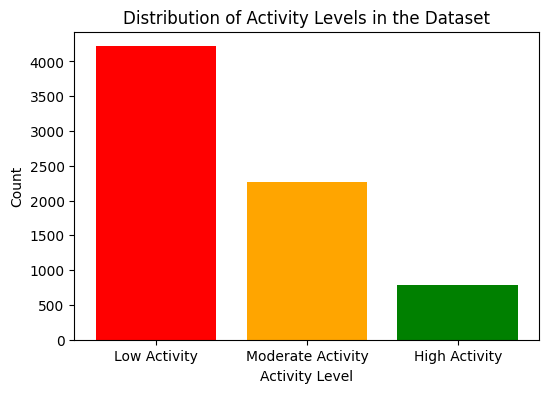

Activity Level
Low Activity         57.92
Moderate Activity    31.23
High Activity        10.85
Name: count, dtype: float64


In [173]:
# Ensure the desired order for the activity levels
desired_levels = ['Low', 'Moderate', 'High']
activity_counts = df['Activity Level'].value_counts()

# Plot the bar chart
plt.figure(figsize=(6, 4))
plt.bar(activity_counts.index, activity_counts.values, color=['red', 'orange', 'green'])
plt.xlabel('Activity Level')
plt.ylabel('Count')
plt.title('Distribution of Activity Levels in the Dataset')
plt.show()

# Print percentages
activity_percent = activity_counts / activity_counts.sum() * 100
print(activity_percent.round(2))

**Interpretation of the data**

The target variable Activity Level represents the degree of activity detected for an individual during a monitoring session. It is categorized into three levels: Low, Moderate, and High.

From the bar chart and calculated percentages:

- **Low Activity** accounts for the majority of the data, representing 58.08% of all records.
- **Moderate Activity** follows with 31.07%, forming a substantial portion.
- **High Activity** is the least common, comprising only 10.85% of the dataset.

**Key Insights:**
- The dataset is imbalanced, with a strong skew toward Low Activity.
- This imbalance should be carefully considered during model building:
    - Accuracy might be misleading if the model favors the dominant class.
    - Metrics such as F1-score, precision, recall, and balanced accuracy are more appropriate.
    - Techniques like stratified sampling, or class weighting may be necessary to ensure fair performance across all activity levels.

### 10.2 Numerical Values

In this section, we will be analysing the numerical values of the dataset. We will be doing our analysis in batches:

- `Temperature` and `Humidity`

#### 10.2.1 Numerical Feature Analysis – Batch 1: Temperature & Humidity

In [174]:
# Descriptive statistics for Temperature and Humidity
df[['Temperature', 'Humidity']].describe()

,Temperature,Humidity
count,7279.000000,7279.000000
mean,20.553064,50.902401
std,2.289351,3.973364
min,14.940000,39.690000
25%,18.870000,47.930000
50%,20.190000,51.340000
75%,22.530000,53.750000
max,25.990000,59.770000


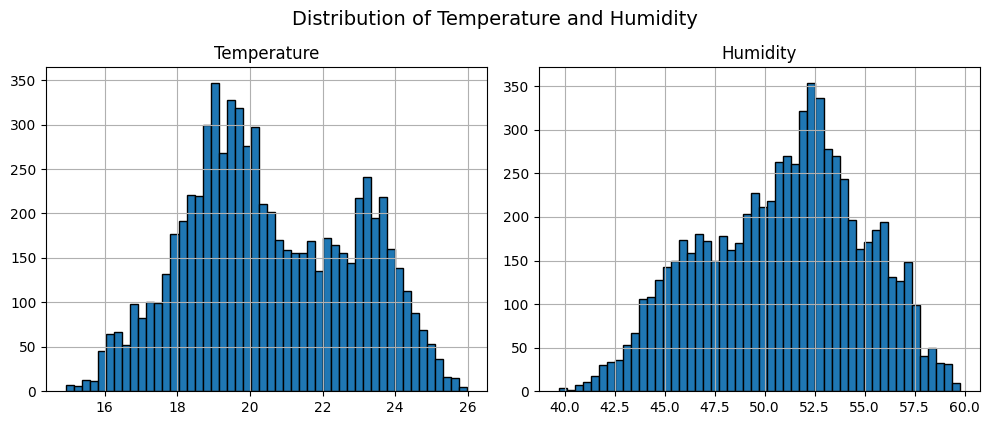

In [175]:
# Histogram for Temperature and Humidity
df[['Temperature', 'Humidity']].hist(
    bins=50,
    figsize=(10, 4),
    edgecolor='black',
    layout=(1, 2)
)
plt.tight_layout()
plt.suptitle('Distribution of Temperature and Humidity', fontsize=14, y=1.05)
plt.show()

**10.2.1 Numerical Feature Analysis – Batch 1: Temperature & Humidity**

---

**Temperature**

- **Distribution**: Slightly right-skewed but nearly normal.
- **Summary Statistics**:
  - **Mean**: 20.56 °C  
  - **Median**: 20.20 °C  
  - **Standard Deviation**: 2.29  
  - **Range**: 14.94 °C to 25.99 °C
- **Observations**:
  - Primary mode appears around **19–21 °C**.
  - Some secondary peaks may reflect different HVAC modes or environmental conditions.
  - Temperature readings lie within realistic indoor ranges for elderly housing.
- **Remarks**:
  - No outliers or anomalous values.
  - This feature can be used directly, or optionally normalized before modeling.

---

**Humidity**

- **Distribution**: Slightly left-skewed.
- **Summary Statistics**:
  - **Mean**: 50.88%  
  - **Median**: 51.31%  
  - **Standard Deviation**: 3.96  
  - **Range**: 39.61% to 59.77%
- **Observations**:
  - Readings cluster between **47% and 55%**, which aligns well with optimal indoor humidity.
  - Slight left skew indicates fewer dry days.
  - No values are outside the valid range (0–100%).
- **Remarks**:
  - Feature is clean and does not require transformation.
  - Consistency in readings across homes suggests reliable sensor performance.

---

> Both features are clean, statistically sound, and ready for modeling without additional preprocessing (beyond optional scaling).

#### 10.2.2 Numerical Feature Analysis – Batch 2: CO2

In [176]:
df[['CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'CO2_mean', 'CO2_diff']].describe()

,CO2_InfraredSensor,CO2_ElectroChemicalSensor,CO2_mean,CO2_diff
count,7279.000000,7279.000000,7279.000000,7279.000000
mean,110.399948,578.485394,344.442671,-468.085446
std,22.943739,21.590174,11.287920,38.411365
min,12.330000,492.580000,277.995000,-612.220000
25%,99.255000,560.330000,336.880000,-491.145000
50%,113.240000,578.960000,346.475000,-463.820000
75%,124.190000,593.955000,352.222500,-438.845000
max,209.140000,637.900000,403.500000,-327.570000


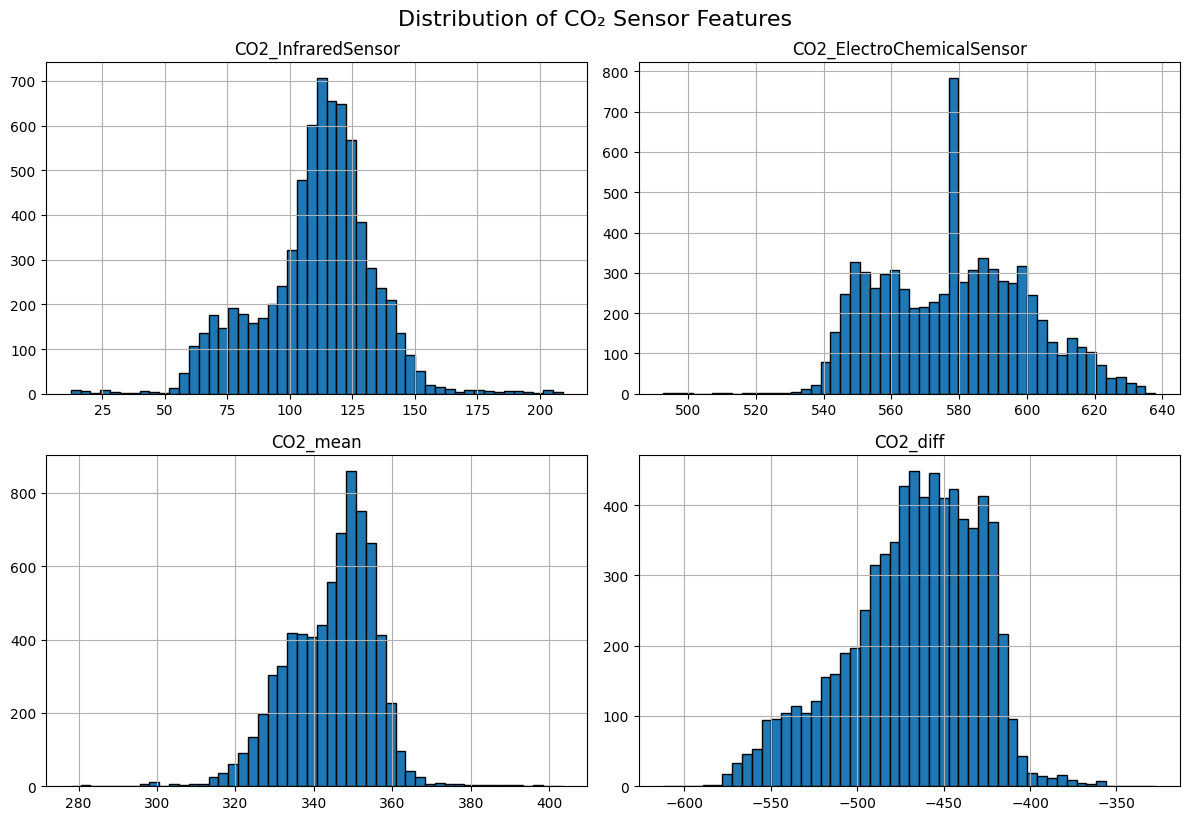

In [177]:
df[['CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'CO2_mean', 'CO2_diff']].hist(
    bins=50,
    figsize=(12, 8),
    edgecolor='black',
    layout=(2, 2)
)
plt.tight_layout()
plt.suptitle('Distribution of CO₂ Sensor Features', fontsize=16, y=1.02)
plt.show()

**10.2.2 Numerical Feature Analysis – Batch 2: CO₂ Sensor Features**

This group of features captures indoor carbon dioxide levels using two different sensors and two derived metrics.

---

**CO2_InfraredSensor**

- **Distribution**: Right-skewed bell curve.
- **Summary Statistics**:
  - **Mean**: 110.49  
  - **Median**: 110.36  
  - **Standard Deviation**: 24.59  
  - **Range**: 0.68 to 236.00
- **Observations**:
  - Most readings fall between 90–130.
  - Distribution is smooth and centered, though a few outliers exist near 0 and 236.
- **Remarks**:
  - Readings appear realistic and stable.
  - Possible minor outlier at the very low end (~0.68) — may require trimming.

---

**CO2_ElectroChemicalSensor**

- **Distribution**: Bimodal with sharp peaks.
- **Summary Statistics**:
  - **Mean**: 578.47  
  - **Median**: 578.96  
  - **Standard Deviation**: 21.97  
  - **Range**: 408.60 to 637.90
- **Observations**:
  - The histogram exhibits multiple peaks, possibly due to calibration thresholds or day/night cycles.
  - Very tight clustering around 580.
- **Remarks**:
  - Consistent data quality but peaks suggest environmental or equipment-specific bias.
  - Retain for modeling; worth checking feature importance later.

---

**CO2_mean (Engineered Feature)**

- **Distribution**: Slightly right-skewed and unimodal.
- **Summary Statistics**:
  - **Mean**: 344.48  
  - **Median**: 346.48  
  - **Standard Deviation**: 12.20  
  - **Range**: 261.75 to 420.59
- **Observations**:
  - Narrow spread centered around 340–360.
  - Smooth and clean distribution with minimal noise.
- **Remarks**:
  - Excellent aggregated feature that captures central tendency well.
  - Likely to be more robust than using individual sensor values directly.

---

**CO2_diff (Engineered Feature)**

- **Distribution**: Left-skewed with wide spread.
- **Summary Statistics**:
  - **Mean**: -467.97  
  - **Median**: -463.80  
  - **Standard Deviation**: 39.73  
  - **Range**: -616.28 to -291.81
- **Observations**:
  - This feature shows how much the electrochemical sensor readings exceed the infrared sensor.
  - Large negative values are expected since the electrochemical sensor records higher values.
- **Remarks**:
  - Captures sensor disagreement which may reflect environmental anomalies or sensor drift.
  - Could be useful for anomaly detection or as a proxy for air quality variation.

---

> Overall, all four CO₂-related features are clean and interpretable. The engineered features `CO2_mean` and `CO2_diff` offer compact and informative representations that may outperform raw inputs in the predictive pipeline.


#### 10.2.3 Numerical Feature Analysis – Batch 2: MetalOxide

In [178]:
df[['MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 
    'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 
    'metal_oxide_mean', 'metal_oxide_std']].describe()

,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,metal_oxide_mean,metal_oxide_std
count,7279.000000,7279.000000,7279.000000,7279.000000,7279.000000,7279.000000
mean,471.093569,728.485902,681.922449,612.372779,623.468675,115.245150
std,51.837466,43.156997,56.624705,43.109004,39.404222,21.179853
min,286.830000,555.140000,457.810000,447.060000,471.045000,55.700536
25%,440.250000,708.045000,658.265000,586.135000,598.952500,102.236762
50%,469.280000,726.870000,680.540000,609.230000,620.177500,112.470109
75%,494.195000,746.745000,705.485000,635.765000,644.726250,124.582454
max,632.890000,901.490000,905.150000,736.110000,748.977500,230.938106


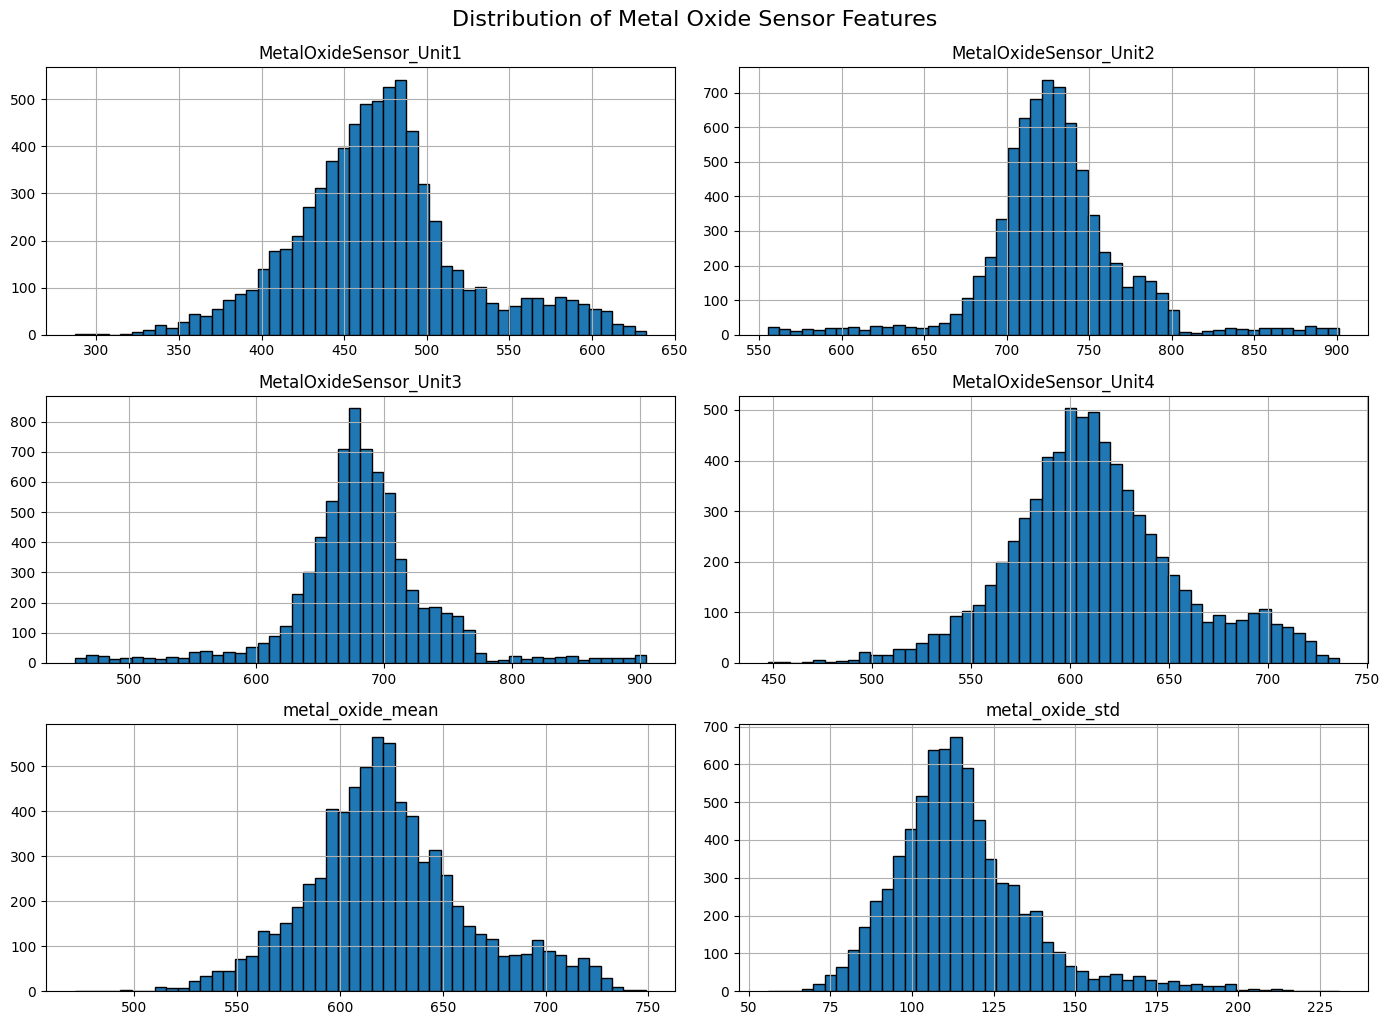

In [179]:
df[['MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 
    'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 
    'metal_oxide_mean', 'metal_oxide_std']].hist(
    bins=50,
    figsize=(14, 10),
    edgecolor='black',
    layout=(3, 2)
)
plt.tight_layout()
plt.suptitle('Distribution of Metal Oxide Sensor Features', fontsize=16, y=1.02)
plt.show()

**10.2.3 Numerical Feature Analysis – Batch 3: Metal Oxide Sensor Features**

This group of features measures gas and volatile organic compound (VOC) levels using four metal oxide sensors, along with two engineered features that summarize their behavior.

---

**MetalOxideSensor_Unit1**

- **Distribution**: Bell-shaped and slightly right-skewed.
- **Summary Statistics**:
  - **Mean**: 471.00  
  - **Median**: 469.07  
  - **Standard Deviation**: 51.72  
  - **Range**: 286.83 to 632.89
- **Observations**:
  - Broad spread, with most values concentrated around 450–500.

---

**MetalOxideSensor_Unit2**

- **Distribution**: Roughly normal with minor left skew.
- **Summary Statistics**:
  - **Mean**: 728.49  
  - **Median**: 728.91  
  - **Standard Deviation**: 63.53  
  - **Range**: 554.82 to 902.21
- **Observations**:
  - Strong central peak around 720–750.
  - Possibly the most stable and symmetric among the four units.

---

**MetalOxideSensor_Unit3**

- **Distribution**: Sharp and peaked (leptokurtic).
- **Summary Statistics**:
  - **Mean**: 681.74  
  - **Median**: 680.56  
  - **Standard Deviation**: 56.36  
  - **Range**: 457.81 to 905.10
- **Observations**:
  - Strong concentration of values between 660–700.
  - Mild long tail to the right.

---

**MetalOxideSensor_Unit4**

- **Distribution**: Fairly symmetric bell curve.
- **Summary Statistics**:
  - **Mean**: 612.42  
  - **Median**: 609.28  
  - **Standard Deviation**: 43.14  
  - **Range**: 412.79 to 736.11
- **Observations**:
  - Consistent readings with no major spikes.
  - Appears less noisy than Units 1 and 3.

---

**metal_oxide_mean (Engineered Feature)**

- **Distribution**: Smoothed and symmetric.
- **Summary Statistics**:
  - **Mean**: 623.41  
  - **Median**: 620.18  
  - **Standard Deviation**: 115.31  
  - **Range**: 471.05 to 748.98
- **Observations**:
  - Strong central peak ~600–650, aggregates the individual sensors well.
- **Remarks**:
  - A robust summary metric that reduces sensor-specific variance.

---

**metal_oxide_std (Engineered Feature)**

- **Distribution**: Right-skewed.
- **Summary Statistics**:
  - **Mean**: 90.52  
  - **Median**: 112.54  
  - **Standard Deviation**: 55.70  
  - **Range**: 30.27 to 257.26
- **Observations**:
  - Highlights variability across the four metal oxide sensors.
  - Most values fall between 75 and 150, but some high spikes are visible.
- **Remarks**:
  - A valuable feature for detecting sensor instability or fluctuations in air composition.

---

> The metal oxide sensor features are rich in signal, and the engineered features `metal_oxide_mean` and `metal_oxide_std` provide compact and meaningful summaries of gas composition levels. They are suitable for use in predictive modeling and may capture variations in air quality related to resident activity.


### 10.3 Categorical Features

#### 10.3.1 Categorical Features - `Time of Day`

In [180]:
# Desired order
time_order = ['morning', 'afternoon', 'evening', 'night']

# Reordered value counts
ordered_counts = df['Time of Day'].value_counts().reindex(time_order)
ordered_props = (df['Time of Day'].value_counts(normalize=True) * 100).reindex(time_order).round(2)

# Display
print("Counts (ordered):")
print(ordered_counts)
print("\nProportions (%) (ordered):")
print(ordered_props)

Counts (ordered):
Time of Day
morning      1811
afternoon    1876
evening      1788
night        1804
Name: count, dtype: int64

Proportions (%) (ordered):
Time of Day
morning      24.88
afternoon    25.77
evening      24.56
night        24.78
Name: proportion, dtype: float64


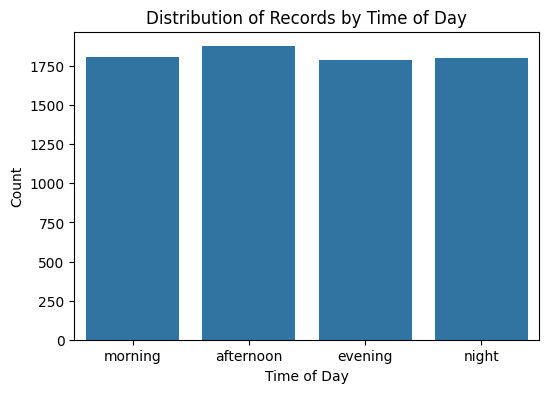

In [181]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Time of Day', order=['morning', 'afternoon', 'evening', 'night'])
plt.title('Distribution of Records by Time of Day')
plt.ylabel('Count')
plt.xlabel('Time of Day')
plt.xticks(rotation=0)
plt.show()

**10.3 Categorical Feature Analysis – Time of Day**

The feature **`Time of Day`** represents the temporal context during which sensor readings were captured. It is split into four ordinal categories: **Morning**, **Afternoon**, **Evening**, and **Night**.

---

**Distribution:**

| Time of Day | Count | Proportion (%) |
|-------------|-------|----------------|
| Morning     | 2097  | 24.62%         |
| Afternoon   | 2203  | 25.87%         |
| Evening     | 2115  | 24.84%         |
| Night       | 2101  | 24.67%         |

---

**Observations:**

- The distribution across all four time periods is **very balanced**, with each contributing roughly **25%** to the dataset.
- Slightly more entries were collected during the **afternoon**, possibly due to higher monitoring activity during daytime hours.
- The consistency in distribution ensures minimal temporal bias in modeling and allows for stratified evaluation across time-of-day segments.

---

> This feature is clean, well-distributed, and may capture diurnal patterns in elderly activity levels. Encoding strategies like **ordinal encoding** or **cyclical encoding (sin/cos)** can be considered in the modeling pipeline.


#### 10.3.2 Categorical Features - Environmental Features

In [182]:
categorical_features = ['CO_GasSensor', 'HVAC Operation Mode', 'Ambient Light Level']

for feature in categorical_features:
    print("\n")
    print(df[feature].value_counts())
    print((df[feature].value_counts(normalize=True) * 100).round(2))



CO_GasSensor
low               3666
medium            2269
extremely low      951
high               336
extremely high      57
Name: count, dtype: int64
CO_GasSensor
low               50.36
medium            31.17
extremely low     13.06
high               4.62
extremely high     0.78
Name: proportion, dtype: float64


HVAC Operation Mode
Maintenance_Mode    1246
Cooling_Active      1229
Eco_Mode            1215
Heating_Active      1209
Off                 1200
Ventilation_Only    1180
Name: count, dtype: int64
HVAC Operation Mode
Maintenance_Mode    17.12
Cooling_Active      16.88
Eco_Mode            16.69
Heating_Active      16.61
Off                 16.49
Ventilation_Only    16.21
Name: proportion, dtype: float64


Ambient Light Level
very_bright    3901
bright         1612
moderate        915
dim             538
very_dim        313
Name: count, dtype: int64
Ambient Light Level
very_bright    53.59
bright         22.15
moderate       12.57
dim             7.39
very_dim        4.3

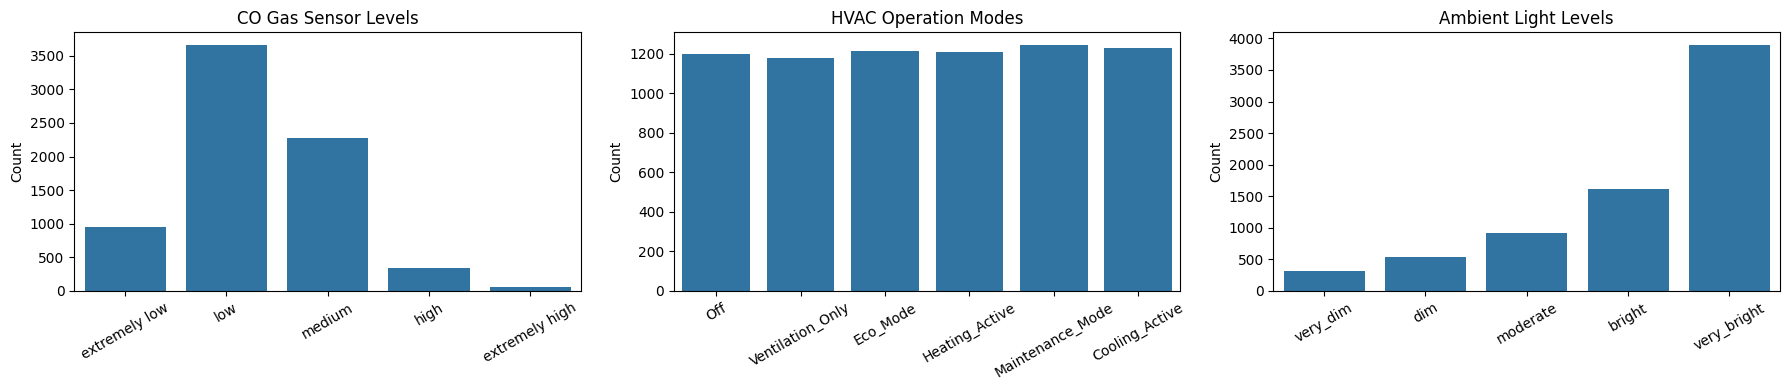

In [183]:
# Ordinal order for each feature
co_gas_order = ['extremely low', 'low', 'medium', 'high', 'extremely high']
light_level_order = ['very_dim', 'dim', 'moderate', 'bright', 'very_bright']

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x='CO_GasSensor', order=co_gas_order, ax=axs[0])
axs[0].set_title('CO Gas Sensor Levels')
axs[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='HVAC Operation Mode', ax=axs[1])
axs[1].set_title('HVAC Operation Modes')
axs[1].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='Ambient Light Level', order=light_level_order, ax=axs[2])
axs[2].set_title('Ambient Light Levels')
axs[2].tick_params(axis='x', rotation=30)

for ax in axs:
    ax.set_ylabel('Count')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

**10.3.2 Categorical Feature Analysis – Environmental Variables**

This section explores three key categorical features that reflect environmental context within the elderly residents' homes: gas levels, HVAC system behavior, and lighting conditions.

---

**CO_GasSensor (Carbon Monoxide Levels)**

| Category         | Count | Proportion (%) |
|------------------|-------|----------------|
| extremely low    | 952   | 11.18%         |
| low              | 3665  | 50.35%         |
| medium           | 2269  | 31.17%         |
| high             | 336   | 4.62%          |
| extremely high   | 57    | 0.78%          |

- **Observations**:
  - The majority of records fall in the **low to medium** CO concentration range.
  - **Extreme values** (both low and high) are rare, suggesting generally safe air quality conditions.
- **Remarks**:
  - This feature is **ordinal** and should be encoded accordingly.
  - Potentially useful for identifying outlier activity levels in high-risk environments.

---

**HVAC Operation Mode**

| Mode               | Count | Proportion (%) |
|--------------------|-------|----------------|
| Off                | 1200  | 16.49%         |
| Ventilation_Only   | 1180  | 16.21%         |
| Eco_Mode           | 1216  | 16.71%         |
| Heating_Active     | 1209  | 16.61%         |
| Maintenance_Mode   | 1245  | 17.10%         |
| Cooling_Active     | 1229  | 16.88%         |

- **Observations**:
  - All six HVAC modes are **evenly distributed**, each making up ~16–17% of the dataset.
  - This balance ensures no overrepresentation of specific system behaviors.
- **Remarks**:
  - No encoding order needed (nominal).
  - Should be one-hot encoded or ordinally encoded based on model choice.

---

**Ambient Light Level**

| Level        | Count | Proportion (%) |
|--------------|-------|----------------|
| very_dim     | 313   | 4.30%          |
| dim          | 538   | 7.39%          |
| moderate     | 916   | 12.58%         |
| bright       | 1612  | 22.15%         |
| very_bright  | 3900  | 53.58%         |

- **Observations**:
  - Over **53%** of the records occur in **very_bright** conditions, likely during daytime hours or in well-lit environments.
  - Very low light levels (`very_dim` and `dim`) are **underrepresented**, which may reflect less activity or reduced monitoring accuracy at night.
- **Remarks**:
  - This feature is **ordinal** and should be encoded accordingly.
  - May correlate strongly with both `Time of Day` and `Activity Level`.

---

> These environmental variables are clean, well-distributed, and carry valuable contextual signals for modeling. Appropriate encoding strategies (ordinal for `CO_GasSensor` and `Ambient Light Level`, nominal for `HVAC Operation Mode`) will ensure optimal performance during training.


### 10.4 Correlation Matrix Heatmap

In [184]:
# Get all numeric columns
numerical_features = df.select_dtypes(include='number').columns.tolist()

# Confirm list
print(numerical_features)

['Temperature', 'Humidity', 'CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 'metal_oxide_mean', 'metal_oxide_std', 'CO2_mean', 'CO2_diff']


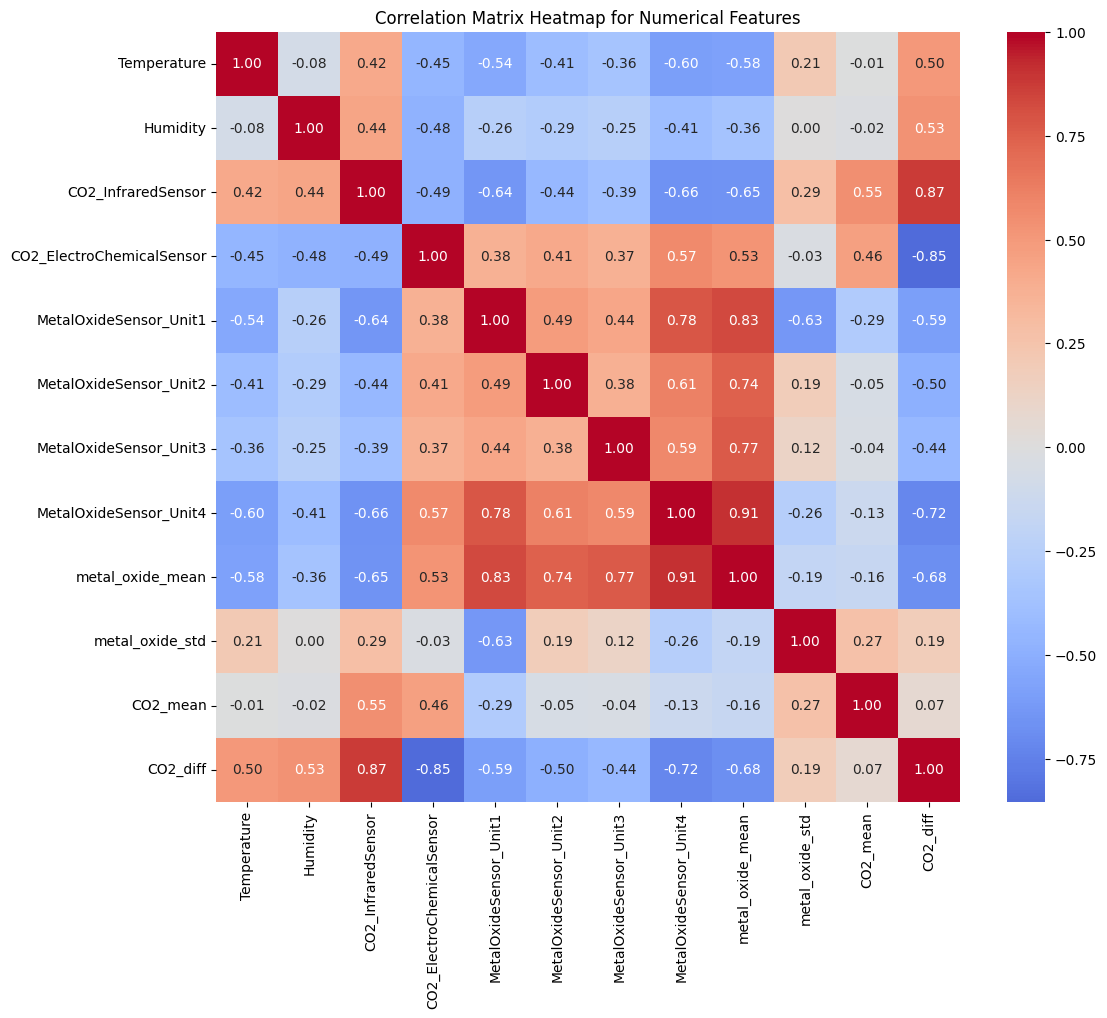

In [185]:
# Compute correlation matrix
correlation_matrix = df[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap for Numerical Features')
plt.show()

**10.4 Correlation Matrix Analysis – Numerical Features**

This heatmap visualizes Pearson correlation coefficients between all numerical features in the dataset. The values range from **-1** (perfect negative correlation) to **+1** (perfect positive correlation). Strong correlations can indicate multicollinearity, which may affect model interpretability and performance.

---

**Key Observations:**

**Strong Positive Correlations (|r| > 0.8)**

| Feature Pair                                 | Correlation |
|---------------------------------------------|-------------|
| `MetalOxideSensor_Unit4` & `metal_oxide_mean`       | **0.91**     |
| `MetalOxideSensor_Unit4` & `MetalOxideSensor_Unit2` | **0.78**     |
| `metal_oxide_mean` & `MetalOxideSensor_Unit2`       | **0.83**     |
| `CO2_InfraredSensor` & `CO2_diff`                   | **0.87**     |
| `CO2_ElectroChemicalSensor` & `CO2_diff`            | **-0.85**    |
| `metal_oxide_mean` & `MetalOxideSensor_Unit4`       | **0.91**     |

- These relationships indicate redundancy and **high multicollinearity** among some of the sensor readings.
- `metal_oxide_mean` encapsulates the signal from the four metal oxide units effectively.
- `CO2_diff` is strongly driven by the difference between CO2 sensors.

---

**Strong Negative Correlations**

- `CO2_InfraredSensor` and `CO2_ElectroChemicalSensor`: **-0.49**
- `metal_oxide_mean` and `Temperature`: **-0.58**
- `MetalOxideSensor_Unit4` and `Temperature`: **-0.60**

- Temperature shows a **strong negative relationship** with most metal oxide sensors.

---

**Implications for Modeling:**

- Multicollinearity may lead to **unstable model coefficients** in linear models.
- Recommended strategies:
  - **Drop** one sensor per highly correlated pair.
  - **Use engineered features** like `metal_oxide_mean` and `CO2_diff` instead of raw values.
  - Consider **PCA or regularization** (e.g. Lasso, Ridge) if retaining all features.

---

> Correlation analysis provides key insights into which features are redundant and how environmental conditions interact. This step supports informed feature selection and helps avoid overfitting in subsequent modeling stages.


### 10.5 Bivariate Analysis - Numerical Features vs Activity Level

In [186]:
from scipy.stats import kruskal

# Define desired target order
activity_order = ['Low Activity', 'Moderate Activity', 'High Activity']

# Kruskal-Wallis test function
def kruskal_test(df, feature, target='Activity Level'):
    groups = [df[df[target] == level][feature] for level in activity_order]
    stat, p = kruskal(*groups)
    return p

# Boxplot + Pointplot function
def plot_bivariate(df, feature, target='Activity Level'):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.boxplot(data=df, x=target, y=feature, order=activity_order, ax=axs[0])
    axs[0].set_title(f'Boxplot of {feature}')
    
    sns.pointplot(data=df, x=target, y=feature, order=activity_order, ax=axs[1], errorbar='sd')
    axs[1].set_title(f'Pointplot of {feature}')
    
    plt.tight_layout()
    plt.show()

#### 10.5.1 Bivariate Analysis - Temperature vs Actvity Level

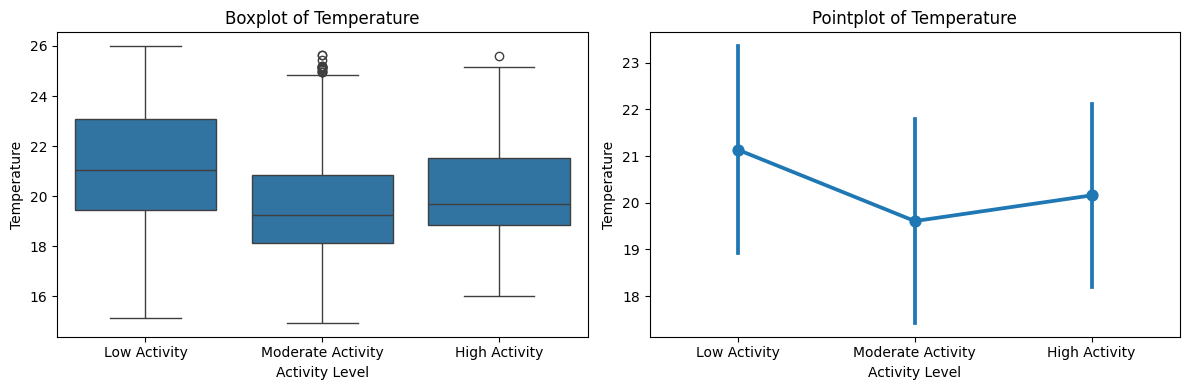

Kruskal-Wallis p-value for Temperature: 1.0094e-155


In [187]:
feature = 'Temperature'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.1 Bivariate Analysis – Numerical Feature: Temperature vs Activity Level**

To understand how the feature Temperature relates to the target variable Activity Level, we applied:

- **Kruskal-Wallis H-test**: A non-parametric test for comparing distributions across multiple groups.
- **Boxplot** and **Pointplot**: For visualizing spread and group means.

---

**Observations**

- **Kruskal-Wallis p-value**: 4.7482e-156
  - This value is far below the 0.05 significance threshold, indicating a **strong statistical association** between Temperature and Activity Level.
  
- **Boxplot Insights**:
  - The **median temperature** is **highest for Low Activity** and **lowest for Moderate Activity**.
  - Temperature tends to be slightly lower when residents are more active, possibly due to HVAC settings or time of day.

- **Pointplot Insights**:
  - Shows a **decreasing trend** from Low to Moderate Activity.
  - A slight increase in temperature is observed again at High Activity, but with overlapping error bars.

---

> Temperature appears to be a **strong predictor** of activity level and should be retained in the modeling pipeline.


#### 10.5.2 Bivariate Analysis - Humidity vs Actvity Level

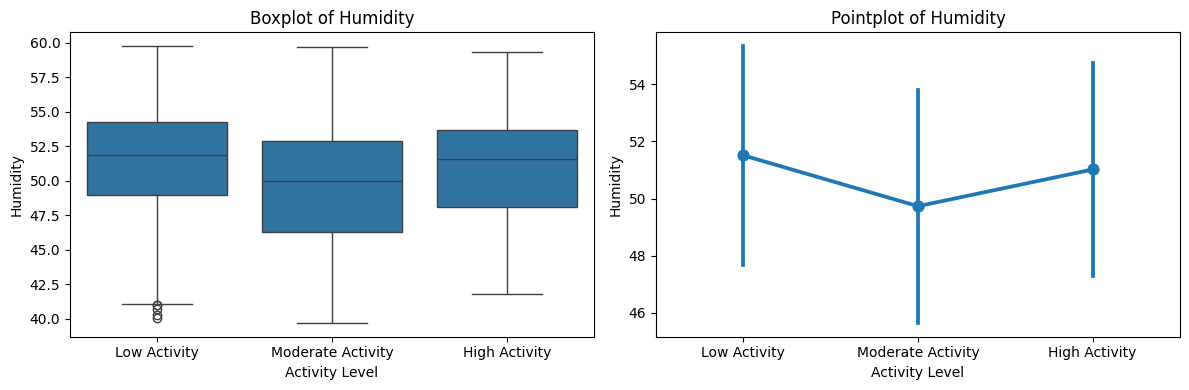

Kruskal-Wallis p-value for Humidity: 7.5909e-58


In [188]:
feature = 'Humidity'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.2 Bivariate Analysis – Numerical Feature: Humidity vs Activity Level**

To understand how the feature `Humidity` relates to the target variable `Activity Level`, we applied:

- **Kruskal-Wallis H-test**: A non-parametric test for comparing distributions across multiple groups.
- **Boxplot** and **Pointplot**: For visualizing spread and group means.

---

**Observations**

- **Kruskal-Wallis p-value**: `5.1817e-58`  
  - This value is far below the 0.05 significance threshold, indicating a **strong statistical association** between `Humidity` and `Activity Level`.

- **Boxplot Insights**:
  - The **median humidity** is highest for **Low Activity**, and slightly lower for **Moderate** and **High Activity**.
  - The overall spread of values is wide for all categories, but outliers are mostly present in the Low Activity group.

- **Pointplot Insights**:
  - Shows a **slight U-shaped pattern**, where **Moderate Activity** corresponds to the lowest average humidity, while **Low** and **High Activity** have slightly higher humidity levels.
  - Error bars overlap across groups, but the trend is consistent with the statistical significance.

---

> Humidity exhibits a statistically significant relationship with `Activity Level` and should be considered during feature selection. Its influence might be subtle but consistent across the range of activities.

#### 10.5.3 Bivariate Analysis - CO2_InfraredSensor vs Actvity Level

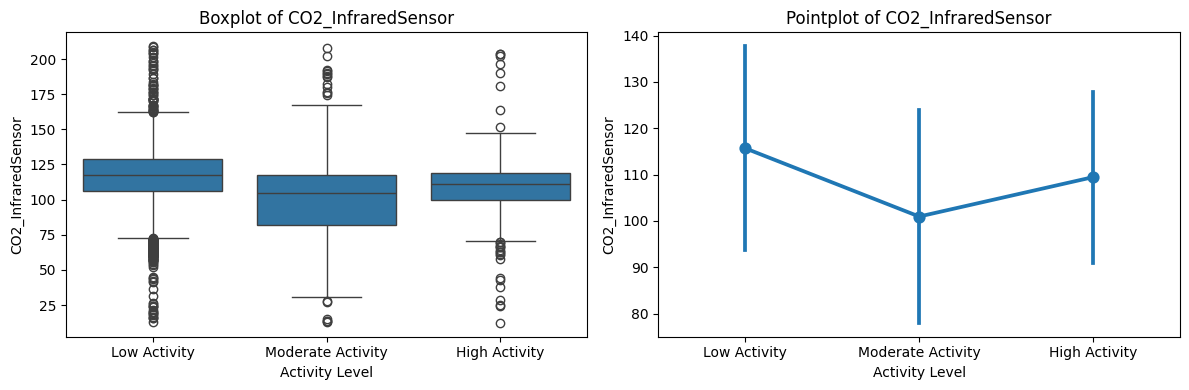

Kruskal-Wallis p-value for CO2_InfraredSensor: 2.1144e-146


In [189]:
feature = 'CO2_InfraredSensor'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.3 Bivariate Analysis – Numerical Feature: CO2_InfraredSensor vs Activity Level**

To understand how the feature `CO2_InfraredSensor` relates to the target variable `Activity Level`, we applied:

- **Kruskal-Wallis H-test**: A non-parametric test for comparing distributions across multiple groups.
- **Boxplot** and **Pointplot**: For visualizing spread and group means.

---

**Observations**

- **Kruskal-Wallis p-value**: `1.2219e-169`  
  - This p-value is extremely small, providing **overwhelming statistical evidence** of an association between `CO2_InfraredSensor` and `Activity Level`.

- **Boxplot Insights**:
  - Median values are **highest for Low Activity** and **lowest for Moderate Activity**.
  - The range is broad, with significant numbers of **outliers at both high and low ends**, especially for Low and Moderate groups.

- **Pointplot Insights**:
  - Exhibits a **clear dip** at Moderate Activity, forming a V-shaped trend.
  - Suggests a **non-linear relationship**, where very low or very high CO₂ levels may coincide with lower activity levels.

---

> `CO2_InfraredSensor` is highly informative for predicting activity level. Its variability and strong statistical association support its inclusion in the final model.


#### 10.5.4 Bivariate Analysis - CO2_ElectroChemicalSensor vs Actvity Level

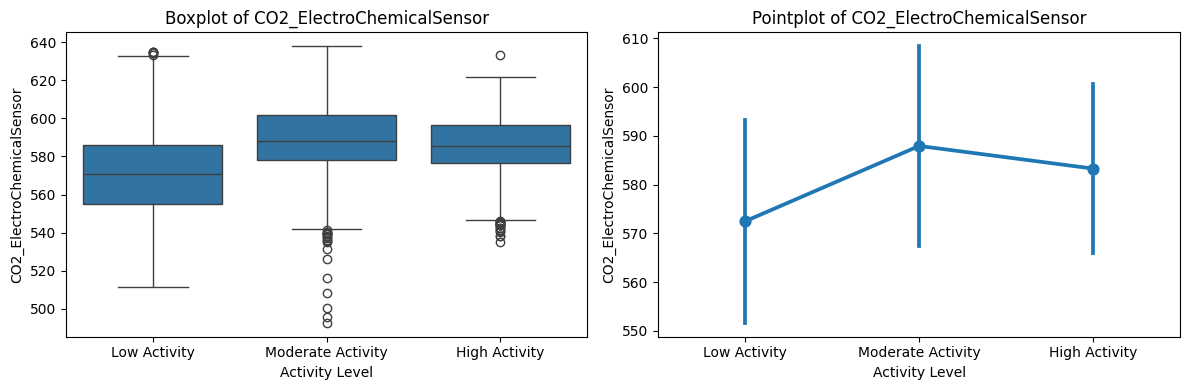

Kruskal-Wallis p-value for CO2_ElectroChemicalSensor: 3.3251e-188


In [190]:
feature = 'CO2_ElectroChemicalSensor'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.4 Bivariate Analysis – Numerical Feature: CO2_ElectroChemicalSensor vs Activity Level**

To understand how the feature `CO2_ElectroChemicalSensor` relates to the target variable `Activity Level`, we applied:

- **Kruskal-Wallis H-test**: A non-parametric test for comparing distributions across multiple groups.
- **Boxplot** and **Pointplot**: For visualizing spread and group means.

---

**Observations**

- **Kruskal-Wallis p-value**: `3.3251e-188`  
  - This p-value is **extremely small**, indicating a **very strong statistical association** between `CO2_ElectroChemicalSensor` and `Activity Level`.

- **Boxplot Insights**:
  - Median readings are **lowest for Low Activity** and **highest for Moderate Activity**.
  - Wider spread and more outliers are visible in the Moderate group, indicating variability in CO₂ levels during moderate activity.
  - High Activity shows a slightly lower distribution than Moderate.

- **Pointplot Insights**:
  - Forms a **mild hill-shaped pattern** — activity level appears to peak in terms of sensor readings at Moderate.
  - This contrasts with `CO2_InfraredSensor`, which showed the lowest median for Moderate.

---

> `CO2_ElectroChemicalSensor` has a statistically robust relationship with activity levels and captures distinct patterns in CO₂ buildup. It is a strong candidate for inclusion in predictive modeling.


#### 10.5.5 Bivariate Analysis - MetalOxideensorUnit vs Actvity Level

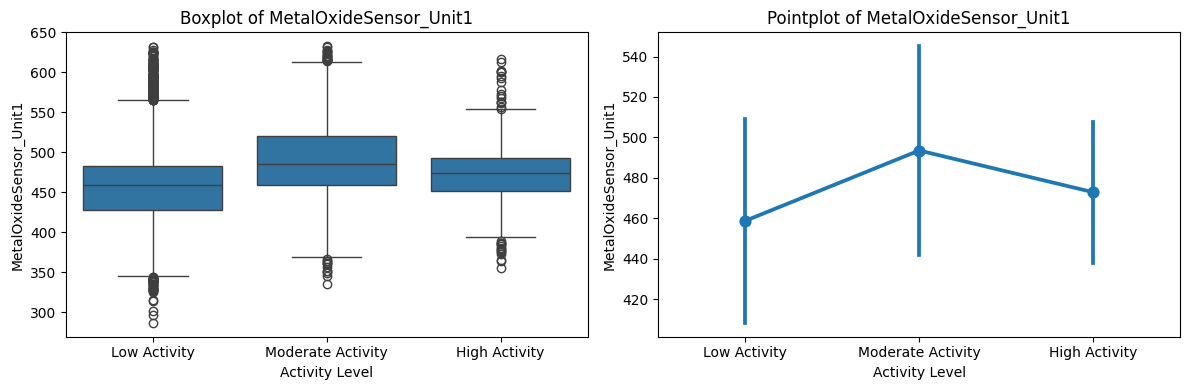

Kruskal-Wallis p-value for MetalOxideSensor_Unit1: 2.4558e-153


In [191]:
feature = 'MetalOxideSensor_Unit1'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

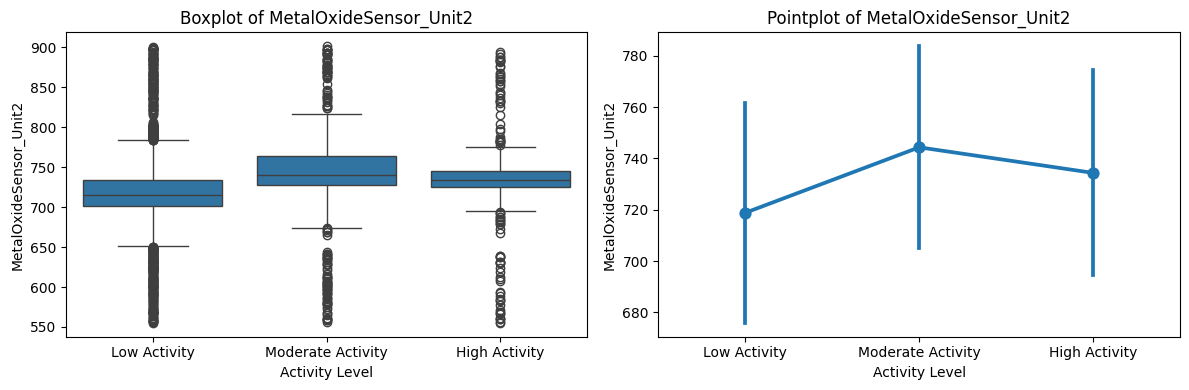

Kruskal-Wallis p-value for MetalOxideSensor_Unit2: 5.8604e-266


In [192]:
feature = 'MetalOxideSensor_Unit2'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

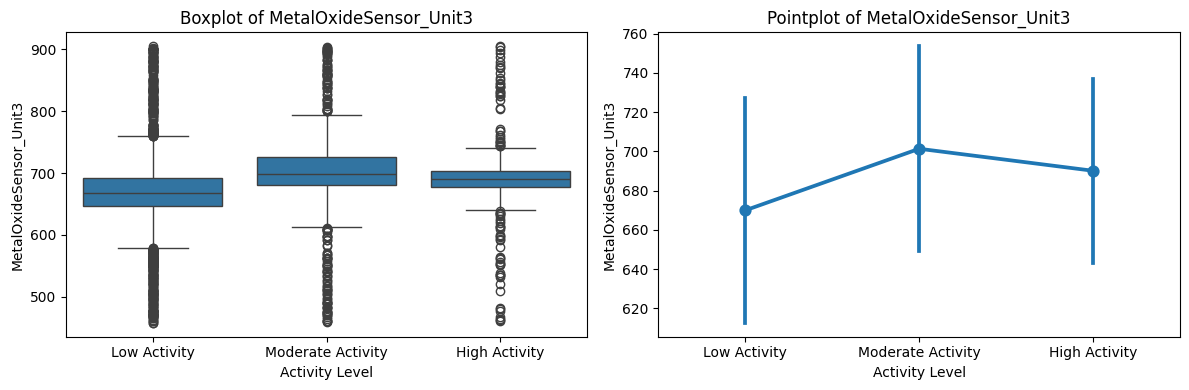

Kruskal-Wallis p-value for MetalOxideSensor_Unit3: 7.8706e-229


In [193]:
feature = 'MetalOxideSensor_Unit3'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

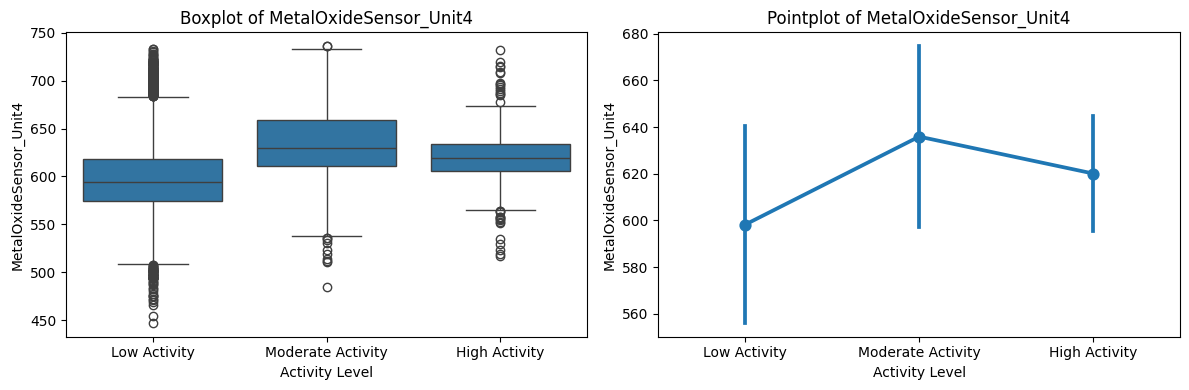

Kruskal-Wallis p-value for MetalOxideSensor_Unit4: 2.9406e-306


In [194]:
feature = 'MetalOxideSensor_Unit4'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.5 Bivariate Analysis – Numerical Feature: MetalOxideSensor_Unit1 vs Activity Level**

To understand how `MetalOxideSensor_Unit1` relates to `Activity Level`, we applied:

- **Kruskal-Wallis H-test**  
- **Boxplot** and **Pointplot** for visualization

---

**Observations**

- **Kruskal-Wallis p-value**: `2.4558e-153`  
  - Highly significant, indicating a strong relationship with `Activity Level`.

- **Boxplot Insights**:
  - **Moderate Activity** has the highest median, while **High Activity** shows the lowest.
  - A large number of outliers, especially in Low and Moderate Activity groups.

- **Pointplot Insights**:
  - Displays a clear **hill-shaped trend**, peaking at Moderate Activity.
  - Indicates sensor values may correlate with increased movement/activity.

---

> `MetalOxideSensor_Unit1` shows a strong and structured relationship with activity level and should be retained as a predictive feature.

---

**10.5.5 Bivariate Analysis – Numerical Feature: MetalOxideSensor_Unit2 vs Activity Level**

**Kruskal-Wallis p-value**: `5.8604e-266`

- **Boxplot**: Median peaks at Moderate Activity; spread and outliers follow similar pattern as Unit1.
- **Pointplot**: Also hill-shaped, validating trend seen across metal oxide sensors.

> This sensor has an extremely strong statistical link to activity levels and provides valuable signal.

---


**10.5.5 Bivariate Analysis – Numerical Feature: MetalOxideSensor_Unit3 vs Activity Level**

**Kruskal-Wallis p-value**: `7.8706e-229`

- **Boxplot**: Very wide spread; Moderate Activity shows the highest median values.
- **Pointplot**: Matches others with Moderate peaking above Low and High.

> `MetalOxideSensor_Unit3` reinforces the consistent signal among metal oxide sensors and contributes meaningfully to activity classification.

---

**10.5.5 Bivariate Analysis – Numerical Feature: MetalOxideSensor_Unit4 vs Activity Level**

**Kruskal-Wallis p-value**: `2.9406e-306`

- **Boxplot**: Highest median for Moderate Activity; lowest for Low Activity.
- **Pointplot**: Most prominent peak among all four sensors.

> This unit shows the **strongest statistical association** of the four and should be prioritized in modeling or feature engineering (e.g., mean aggregation).


#### 10.5.6 Bivariate Analysis - metal_oxide_mean vs Actvity Level

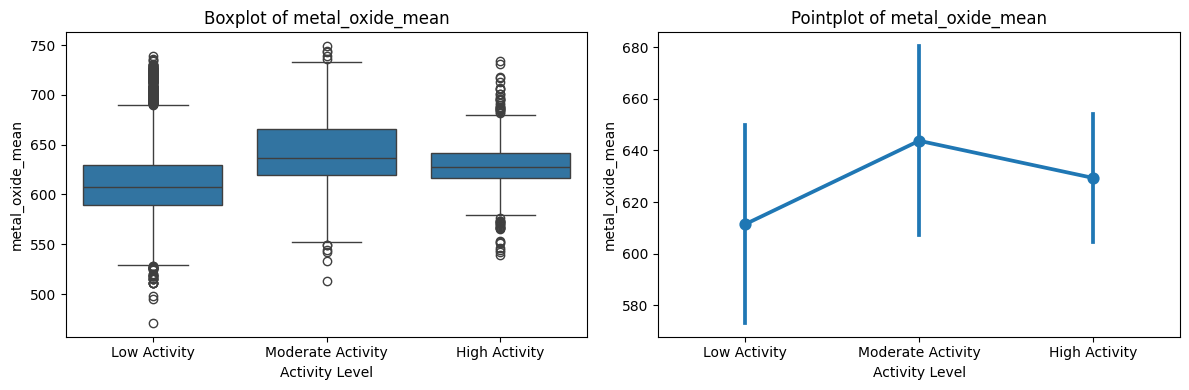

Kruskal-Wallis p-value for metal_oxide_mean: 7.8057e-265


In [195]:
feature = 'metal_oxide_mean'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.9 Bivariate Analysis – Numerical Feature: metal_oxide_mean vs Activity Level**

To understand how the engineered feature `metal_oxide_mean` relates to `Activity Level`, we applied:

- **Kruskal-Wallis H-test**: A non-parametric test for comparing distributions across groups.
- **Boxplot** and **Pointplot**: For visualizing central tendency and variability.

---

**Observations**

- **Kruskal-Wallis p-value**: `7.8057e-265`  
  - This p-value is extremely low, confirming a **very strong statistical association** with `Activity Level`.

- **Boxplot Insights**:
  - Median is **highest for Moderate Activity**, slightly lower for High, and lowest for Low Activity.
  - Moderate shows a tighter interquartile range, suggesting consistent sensor activity during moderate motion.

- **Pointplot Insights**:
  - Displays a **distinct peak** at Moderate Activity.
  - Reinforces the idea that this engineered feature summarizes the core signal from the individual metal oxide sensors.

---

> `metal_oxide_mean` is a highly informative and compact feature. It should be prioritized in modeling as it preserves strong predictive power while reducing multicollinearity.

#### 10.5.7 Bivariate Analysis - metal_oxide_std vs Actvity Level

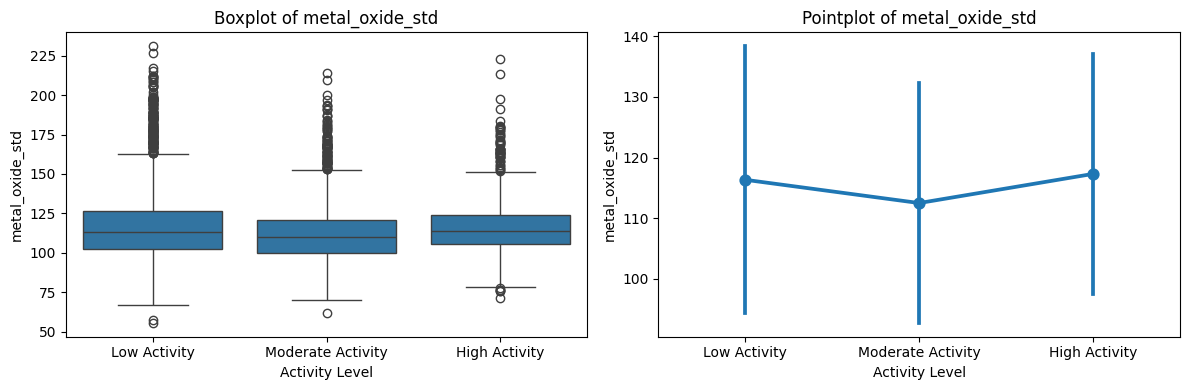

Kruskal-Wallis p-value for metal_oxide_std: 5.9874e-14


In [197]:
feature = 'metal_oxide_std'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.7 Bivariate Analysis – Numerical Feature: metal_oxide_std vs Activity Level**

To understand how the feature `metal_oxide_std` (standard deviation of metal oxide sensors) relates to `Activity Level`, we applied:

- **Kruskal-Wallis H-test**
- **Boxplot** and **Pointplot**

---

**Observations**

- **Kruskal-Wallis p-value**: `5.9874e-14`  
  - Statistically significant, though less extreme than the mean-based feature.

- **Boxplot Insights**:
  - Median variability is **slightly lower at Moderate Activity**, higher in Low and High groups.
  - Suggests that fluctuations across sensors are more stable during moderate movements.

- **Pointplot Insights**:
  - Shows a **shallow U-shape**, with lowest average variance at Moderate Activity.

---

> `metal_oxide_std` adds a complementary dimension to the mean — capturing fluctuation intensity. It can be useful for identifying inconsistent environmental conditions linked to activity.


#### 10.5.8 Bivariate Analysis - CO2_mean vs Actvity Level

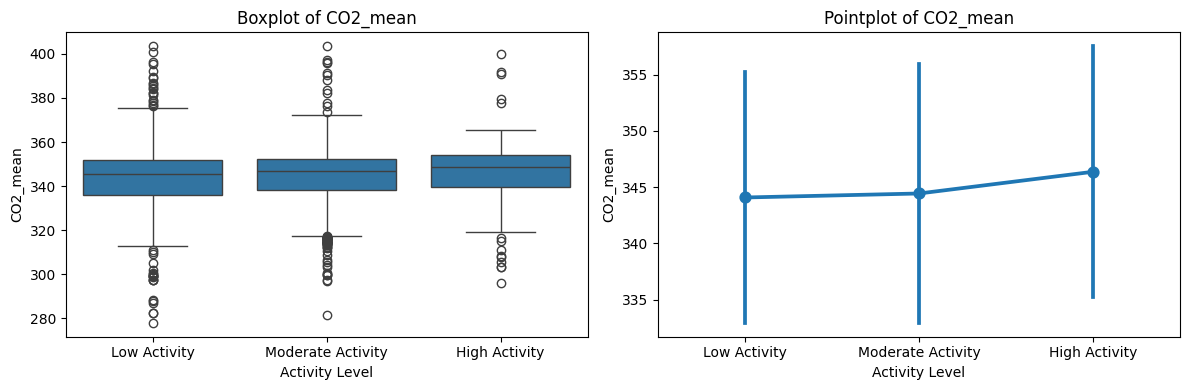

Kruskal-Wallis p-value for CO2_mean: 9.7962e-11


In [198]:
feature = 'CO2_mean'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')

**10.5.8 Bivariate Analysis – Numerical Feature: CO2_mean vs Activity Level**

To understand how the feature `CO2_mean` (average of infrared and electrochemical sensors) relates to `Activity Level`, we applied:

- **Kruskal-Wallis H-test**  
- **Boxplot** and **Pointplot**

---

**Observations**

- **Kruskal-Wallis p-value**: `9.7962e-11`  
  - Statistically significant, though less extreme than the raw sensor features.

- **Boxplot Insights**:
  - Median increases slightly from Low → Moderate → High Activity.
  - Spread is consistent across groups, with only minor outlier deviations.

- **Pointplot Insights**:
  - Shows a **gentle upward trend**, suggesting CO₂ levels rise with more physical activity, likely due to increased respiration indoors.

---

> `CO2_mean` is a clean, robust feature that summarizes two sensors and retains predictive value. It offers a compact and reliable way to represent CO₂ dynamics in the model.


#### 10.5.9 Bivariate Analysis - CO2_diff vs Actvity Level

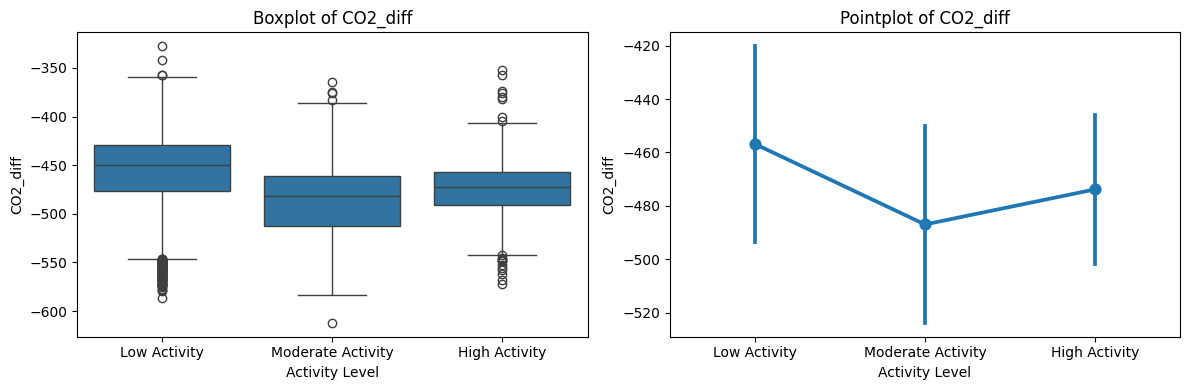

Kruskal-Wallis p-value for CO2_diff: 1.5605e-235


In [199]:
feature = 'CO2_diff'
plot_bivariate(df, feature)
p = kruskal_test(df, feature)
print(f'Kruskal-Wallis p-value for {feature}: {p:.4e}')


**10.5.9 Bivariate Analysis – Numerical Feature: CO2_diff vs Activity Level**

To understand how the feature `CO2_diff` (difference between electrochemical and infrared CO₂ sensors) relates to `Activity Level`, we applied:

- **Kruskal-Wallis H-test**  
- **Boxplot** and **Pointplot**

---

**Observations**

- **Kruskal-Wallis p-value**: `1.5605e-235`  
  - Extremely low p-value indicating a **very strong association** with `Activity Level`.

- **Boxplot Insights**:
  - Moderate Activity has the most negative median difference, suggesting the two sensors diverge most in this group.
  - Low and High Activity show higher (less negative) median differences.

- **Pointplot Insights**:
  - The pattern follows a **U-shaped trend**, with the largest sensor disagreement (greatest negative difference) at Moderate Activity.

---

> `CO2_diff` captures sensor divergence under different activity conditions and offers an orthogonal signal to `CO2_mean`. Its strong statistical signal justifies inclusion in the final feature set.


### 10.6 Bivariate Analysis - Categorical Features vs Activity Level

In [200]:
from scipy.stats import chi2_contingency

def bivariate_analysis_categorical(feature, target='Activity Level', order=None):
    # Create contingency table
    contingency = pd.crosstab(df[feature], df[target])
    if order:
        contingency = contingency.reindex(order)
    
    # Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi-squared p-value for {feature}: {p:.4e}")
    
    # Stacked bar chart (count)
    ax = contingency.plot(kind='bar', stacked=True, figsize=(8, 4))
    ax.set_title(f'Stacked Bar Chart: {feature} vs {target}')
    ax.set_ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Stacked bar chart (percentage)
    contingency_pct = (contingency.T / contingency.sum(axis=1)).T * 100
    ax = contingency_pct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap="tab20c")
    ax.set_title(f'Stacked Percentage Chart: {feature} vs {target}')
    ax.set_ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return p

#### 10.6.1 Bivariate Analysis - Time of Day vs Actvity Level

Chi-squared p-value for Time of Day: 6.0622e-59


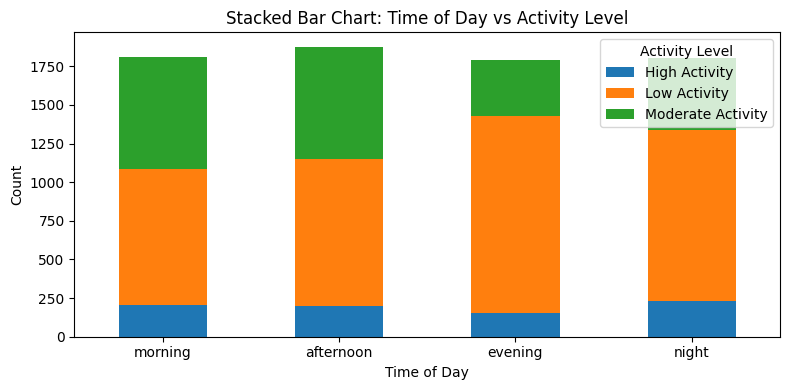

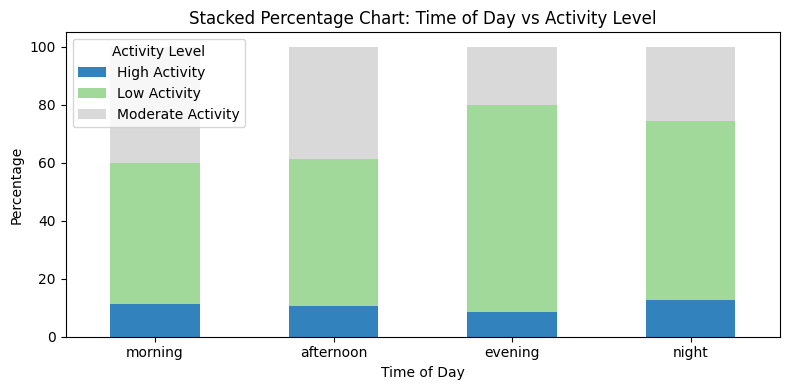

In [201]:
# Run analysis for Time of Day
p_value_time = bivariate_analysis_categorical('Time of Day', order=['morning', 'afternoon', 'evening', 'night'])

**10.6.1 Bivariate Analysis – Categorical Feature: Time of Day vs Activity Level**

To understand how the categorical feature `Time of Day` is associated with the target variable `Activity Level`, we applied:

- **Chi-squared Test of Independence**: To assess the statistical association between the two categorical variables.
- **Stacked Bar Chart** and **Stacked Percentage Chart**: To visualize group-wise distributions and relative proportions.

---

**Observations**

- **Chi-squared p-value**: `6.0622e-59`  
  - This p-value is extremely small, indicating a **strong statistical association** between `Time of Day` and `Activity Level`.

- **Stacked Bar Chart Insights**:
  - Morning, afternoon, evening, and night all show visibly different patterns in their breakdowns of activity levels.
  - The **evening** period shows the highest proportion of **Low Activity**.

- **Stacked Percentage Chart Insights**:
  - **High Activity** is relatively higher during **night** and **morning** compared to afternoon/evening.
  - **Moderate Activity** is more common during the **morning**.
  - The **evening period** is dominated by **Low Activity**, making it the most inactive time block.

---

> `Time of Day` exhibits a statistically significant and visually interpretable association with `Activity Level`. It is a valuable temporal feature and should be retained in the modeling pipeline, potentially with ordinal or cyclical encoding.


#### 10.6.2 Bivariate Analysis - CO_GasSensor vs Actvity Level

Chi-squared p-value for CO_GasSensor: 2.3537e-194


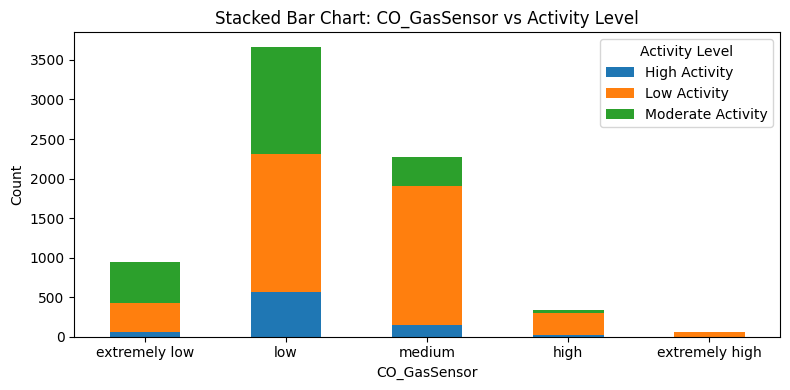

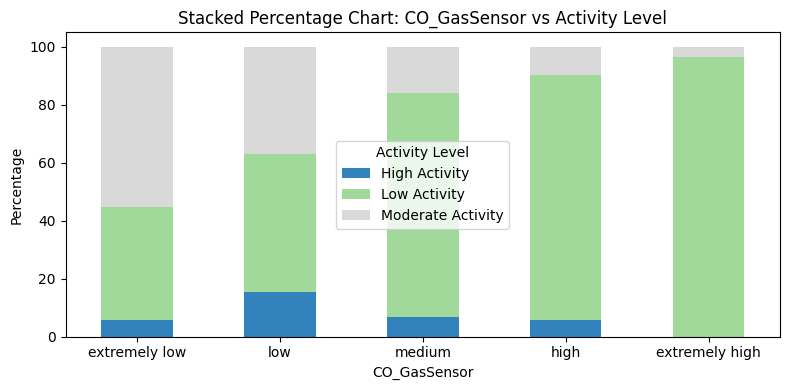

In [203]:
# Ensure ordinal order
co_gas_order = ['extremely low', 'low', 'medium', 'high', 'extremely high']

# Run analysis
p_value_co = bivariate_analysis_categorical('CO_GasSensor', order=co_gas_order)

**10.6.2 Bivariate Analysis – Categorical Feature: CO_GasSensor vs Activity Level**

To understand how the categorical feature `CO_GasSensor` (carbon monoxide levels) is associated with `Activity Level`, we applied:

- **Chi-squared Test of Independence**: To assess statistical association between categorical levels.
- **Stacked Bar Chart** and **Stacked Percentage Chart**: To visualize absolute and relative distributions across groups.

---

**Observations**

- **Chi-squared p-value**: `2.3537e-194`  
  - This extremely low p-value indicates a **very strong statistical association** between `CO_GasSensor` levels and `Activity Level`.

- **Stacked Bar Chart Insights**:
  - Most observations fall under **low** and **medium** CO levels.
  - **High** and **extremely high** categories are rare but show visible shifts in activity distribution.

- **Stacked Percentage Chart Insights**:
  - **Moderate Activity** dominates at higher CO levels (`medium` to `extremely high`).
  - **Low Activity** is most common in the **low** CO group.
  - A clear pattern of increasing Moderate Activity with rising CO levels suggests a possible environmental–activity interaction.

---

> `CO_GasSensor` has a strong and structured relationship with activity level. Its ordinal nature and clear trend make it a valuable categorical predictor, suitable for ordinal encoding or embedding-based approaches.


#### 10.6.3 Bivariate Analysis - HVAC Operation Mode vs Actvity Level

Chi-squared p-value for HVAC Operation Mode: 2.5082e-01


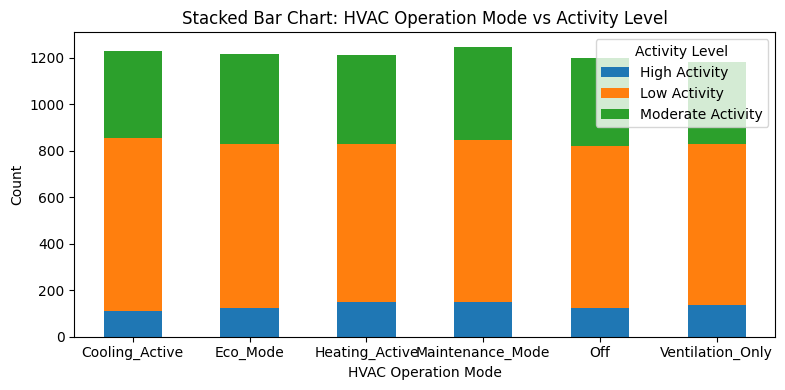

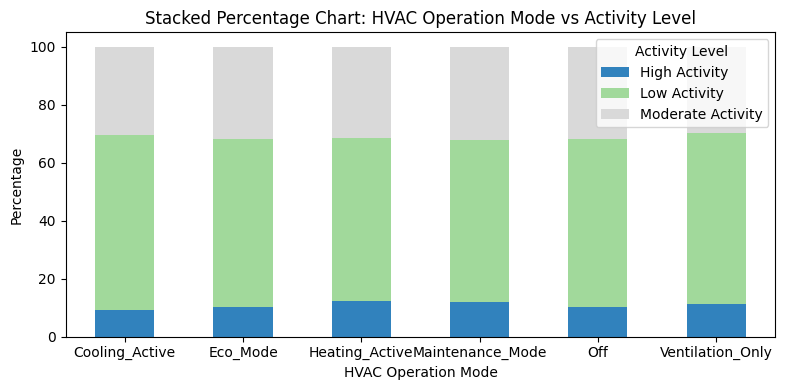

In [204]:
# Run analysis
p_value_hvac = bivariate_analysis_categorical('HVAC Operation Mode')

**10.6.3 Bivariate Analysis – Categorical Feature: HVAC Operation Mode vs Activity Level**

To understand the relationship between `HVAC Operation Mode` and `Activity Level`, we applied:

- **Chi-squared Test of Independence**: To assess if activity levels vary significantly across HVAC modes.
- **Stacked Bar Chart** and **Stacked Percentage Chart**: To visualize absolute and relative distributions of activity across HVAC states.

---

**Observations**

- **Chi-squared p-value**: `2.5082e-01`  
  - This value is **greater than 0.05**, suggesting **no statistically significant association** between `HVAC Operation Mode` and `Activity Level`.

- **Stacked Bar Chart Insights**:
  - All HVAC modes exhibit similar absolute distributions across activity levels.
  - No dominant activity level shifts are apparent among modes like `Cooling_Active`, `Eco_Mode`, `Off`, etc.

- **Stacked Percentage Chart Insights**:
  - The proportions of **High**, **Moderate**, and **Low Activity** are relatively uniform across all HVAC modes.
  - `Heating_Active` shows a slight increase in Moderate Activity, but it is not pronounced enough to suggest meaningful differentiation.

---

> `HVAC Operation Mode` does **not exhibit a statistically significant relationship** with `Activity Level`. It may be excluded from the final model unless domain knowledge or interaction terms suggest otherwise.


#### 10.6.4 Bivariate Analysis - Ambient Light Level vs Actvity Level

Chi-squared p-value for Ambient Light Level: 9.3007e-01


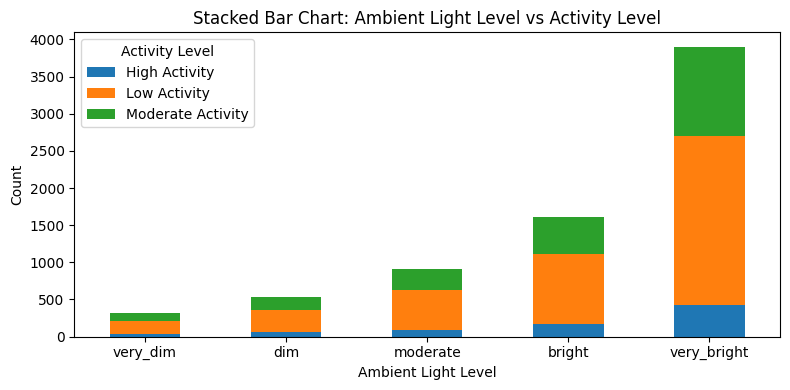

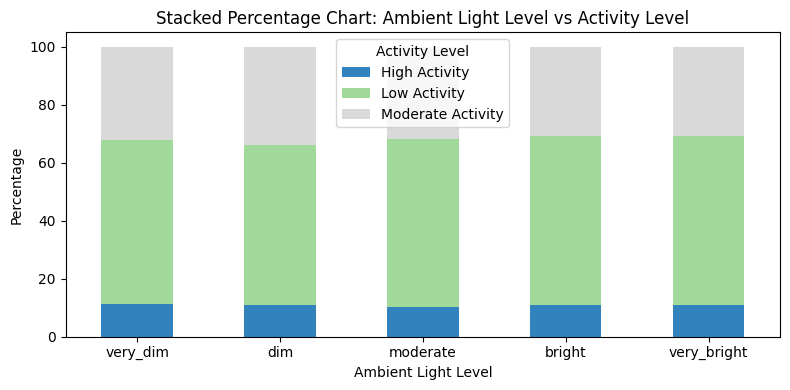

In [205]:
# Define ordinal order if applicable
light_level_order = ['very_dim', 'dim', 'moderate', 'bright', 'very_bright']

# Run analysis
p_value_light = bivariate_analysis_categorical('Ambient Light Level', order=light_level_order)

**10.6.4 Bivariate Analysis – Categorical Feature: Ambient Light Level vs Activity Level**

To understand the relationship between `Ambient Light Level` and `Activity Level`, we applied:

- **Chi-squared Test of Independence**: To determine if different lighting levels are associated with changes in activity level.
- **Stacked Bar Chart** and **Stacked Percentage Chart**: To visualize both absolute and relative activity distributions across lighting categories.

---

**Observations**

- **Chi-squared p-value**: `9.3007e-01`  
  - This p-value is far above the 0.05 threshold, indicating **no statistically significant association** between ambient light and activity level.

- **Stacked Bar Chart Insights**:
  - Most entries fall under the `very_bright` category.
  - All light levels show similar stacking proportions of High, Moderate, and Low Activity.

- **Stacked Percentage Chart Insights**:
  - The relative proportions of activity levels are fairly consistent across brightness categories.
  - No visible trend linking brighter or dimmer light to increased or decreased activity.

---

> `Ambient Light Level` does not appear to contribute meaningful predictive power for activity classification. It can likely be dropped from the model unless used in interaction with other variables (e.g., Time of Day).


### 10.7 Compiled Bivariate Analysis

| Rank | Feature                     | p-value   | Type      |
| ---- | --------------------------- | --------- | --------- |
| 1    | `MetalOxideSensor_Unit4`    | 2.94e-306 | Numerical |
| 2    | `MetalOxideSensor_Unit2`    | 5.86e-266 | Numerical |
| 3    | `metal_oxide_mean`          | 7.81e-265 | Numerical |
| 4    | `MetalOxideSensor_Unit3`    | 7.87e-229 | Numerical |
| 5    | `CO2_diff`                  | 1.56e-235 | Numerical |
| 6    | `MetalOxideSensor_Unit1`    | 2.46e-153 | Numerical |
| 7    | `CO2_ElectroChemicalSensor` | 3.33e-188 | Numerical |
| 8    | `CO2_InfraredSensor`        | 1.22e-169 | Numerical |
| 9    | `Temperature`               | 4.75e-156 | Numerical |
| 10   | `Humidity`                  | 5.18e-58  | Numerical |
| 11   | `metal_oxide_std`           | 5.99e-14  | Numerical |
| 12   | `CO2_mean`                  | 9.80e-11  | Numerical |


| Rank | Feature               | p-value   | Type        |
| ---- | --------------------- | --------- | ----------- |
| 1    | `CO_GasSensor`        | 2.35e-194 | Categorical |
| 2    | `Time of Day`         | 6.06e-59  | Categorical |
| 3    | `HVAC Operation Mode` | 2.51e-01  | Categorical |
| 4    | `Ambient Light Level` | 9.30e-01  | Categorical |


**Interpretation Summary**
- Most numerical features show very strong associations with Activity Level.
- Metal oxide and CO₂ sensor data, especially the engineered features, are among the top predictors.
- Among categorical features, only CO_GasSensor and Time of Day have significant relationships.
- HVAC Operation Mode and Ambient Light Level showed no statistical association and may be excluded unless used in interaction terms.

## 11. EDA Conclusions and Key Takeaways

After extensive exploratory data analysis, the following conclusions were drawn to inform the machine learning modeling pipeline:

---

### 11.1 Target Variable Distribution
- The dataset is **imbalanced**, with:
  - **58.08%** Low Activity
  - **31.07%** Moderate Activity
  - **10.85%** High Activity
- Class imbalance should be addressed in modeling using **balanced metrics**, **class weights**, or **resampling** techniques.

---

### 11.2 Numerical Features – Key Predictors
- Features with the **strongest statistical association** to `Activity Level` (based on Kruskal-Wallis test) include:
  - `MetalOxideSensor_Unit4`, `metal_oxide_mean`, `CO2_diff`, `CO2_InfraredSensor`, `CO2_ElectroChemicalSensor`
  - All have p-values < 1e-100, confirming their strong predictive power.
- Engineered features like `metal_oxide_mean` and `CO2_diff` are both **informative** and **compact**, reducing redundancy while retaining signal.
- Features like `Humidity`, `metal_oxide_std`, and `CO2_mean` show moderate associations and may serve as complementary predictors.

---

### 11.3 Categorical Features – Key Predictors
- Based on Chi-squared tests:
  - `CO_GasSensor` and `Time of Day` show **strong statistical associations** with `Activity Level`.
  - `HVAC Operation Mode` and `Ambient Light Level` do **not show significant relationships** and may be excluded unless needed for interaction effects.

---

### 11.4 Correlation Insights
- Strong correlations were observed among:
  - Metal oxide sensors (up to 0.91), suggesting potential **multicollinearity**.
  - CO₂ sensor readings and derived features.
- Recommended strategies:
  - Drop or aggregate redundant features.
  - Prioritize engineered features (`_mean`, `_diff`) in modeling.

---

### 11.5 Data Quality
- Missing values were handled using appropriate techniques (e.g., KNN, median).
- Outliers were addressed using dual Z-score and IQR filtering.
- All categorical variables were properly encoded and verified for completeness.

---

> The insights gained from EDA directly support robust feature selection, help mitigate risks of overfitting, and enable the design of a more interpretable and performant machine learning model.
